<a href="https://colab.research.google.com/github/kawastony/grok-notes-version-2/blob/main/Cosmic_plank_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Frozen: w0=-0.8090169944, wa=-0.6180339887
z_cross=0.4472135955
R_cone=1.5138679161
=== Test A: CC + DESI BAO (summary cov) ===
phi    chi2=   31.28  H0=67.84  Om=0.3020  rd=147.52
lcdm   chi2=   31.92  H0=69.85  Om=0.2813  rd=147.46
paste  chi2=   32.00  H0=67.58  Om=0.2694  rd=147.22

=== Test B: f(z) linear fluid Om=0.30 ===
     z     f_LCDM      f_phi    ratio
  0.00     0.5128     0.5114   0.9974
  0.38     0.7049     0.6874   0.9751
  0.51     0.7526     0.7367   0.9789
  0.61     0.7837     0.7701   0.9826
  1.00     0.8693     0.8659   0.9961
NOTE: PPF treatment requires CLASS/CAMB; this is fluid-only approximation.
Downloaded SPARC Table 1

=== Test C: SPARC Q=1 BTFR residuals ===
N=83
mean res a0: -0.1613 rms=0.2466
mean res R:  +0.0188 rms=0.2466
corr(logV, resR)=-0.403


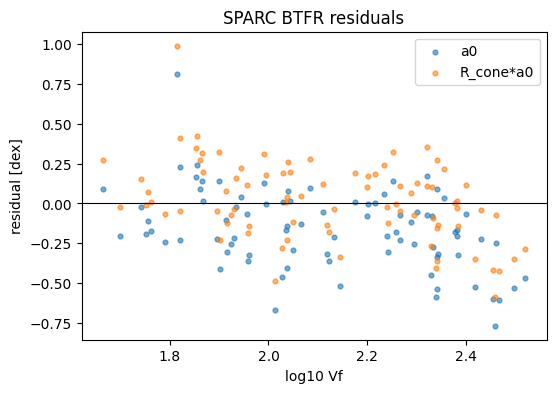


=== Cobaya YAML skeleton (paste to file) ===

# Save as frozen_phi.yaml and run: cobaya-run frozen_phi.yaml
theory:
  classy:
    extra_args:
      # Enable PPF for phantom crossing if your CLASS build supports it:
      # use_ppf: yes
likelihood:
  # Uncomment after installing bao_data / planck likelihoods:
  # bao.desi_dr1.desi_bao_all: null   # or path to desi_2024_* from CobayaSampler/bao_data
  # planck_2018_highl_plik.TTTEEE: null
  # planck_2018_lowl.TT: null
params:
  w0_fld:
    value: -0.8090169944   # FROZEN
  wa_fld:
    value: -0.6180339887   # FROZEN
  H0:
    prior: {min: 50, max: 90}
    ref: 68
  omega_b:
    prior: {min: 0.01, max: 0.05}
  omega_cdm:
    prior: {min: 0.05, max: 0.3}
  # ... standard Planck nuisances ...
sampler:
  mcmc:
    Rminus1_stop: 0.05
output: chains/frozen_phi


=== DONE hard-test draft ===
Report: chi2 table, growth ratios, SPARC mean residuals, any Cobaya Δχ^2.


In [ ]:
# Colab Hard Tests for Frozen-φ Geometric DE + R_cone Bridge
# ============================================================
# Copy each CELL into Google Colab in order.

# Frozen point (exact):
#   w0 = -phi/2 ≈ -0.8090169944
#   wa = -1/phi ≈ -0.6180339887
#   R_cone = sqrt(6)/phi ≈ 1.513867916

# Tests included:
#   A. Late-time χ^2 (CC + DESI summary BAO + Pantheon+ STAT+SYS if available)
#   B. Growth rate comparison (linear fluid; PPF note)
#   C. SPARC BTFR residuals with fixed R_cone
#   D. Optional Cobaya skeleton (run only if cobaya+classy installed)

# Author: grok-notes-version-2 / 20 Sep 2026


# ============================================================
# CELL 0 — Installs (run once)
# ============================================================
!pip install -q numpy scipy matplotlib pandas
# Optional heavy stack (only if doing Cobaya):
# !pip install cobaya classy getdist

# ============================================================
# CELL 1 — Frozen constants + cosmology helpers
# ============================================================
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import quad, solve_ivp
import matplotlib.pyplot as plt

c = 299792.458  # km/s
phi = (1 + np.sqrt(5)) / 2
W0_PHI = -phi / 2
WA_PHI = -1 / phi
R_CONE = np.sqrt(6) / phi
print(f"Frozen: w0={W0_PHI:.10f}, wa={WA_PHI:.10f}")
print(f"z_cross={1/np.sqrt(5):.10f}")
print(f"R_cone={R_CONE:.10f}")

def f_de(z, w0, wa):
    return (1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*z/(1+z+1e-15))

def E(z, Om, w0, wa):
    return np.sqrt(Om*(1+z)**3 + (1-Om)*f_de(z, w0, wa))

def H(z, H0, Om, w0, wa):
    return H0 * E(z, Om, w0, wa)

def Dc(z, H0, Om, w0, wa):
    val, _ = quad(lambda zp: c/H(zp, H0, Om, w0, wa), 0, z, epsabs=1e-3)
    return val

def DV(z, H0, Om, w0, wa):
    dm = Dc(z, H0, Om, w0, wa)
    return (z * c * dm**2 / H(z, H0, Om, w0, wa))**(1/3)

# ============================================================
# CELL 2 — Test A: CC + DESI BAO summary χ^2 (frozen vs LCDM vs paste)
# ============================================================
CC = np.array([
    [0.07,69,19.6],[0.09,69,12],[0.12,68.6,26.2],[0.17,83,8],[0.179,75,4],
    [0.199,75,5],[0.20,72.9,29.6],[0.27,77,14],[0.28,88.8,36.6],[0.352,83,14],
    [0.3802,83,13.5],[0.4004,77,10.2],[0.4247,87.1,11.2],[0.4497,92.8,12.9],
    [0.47,89,50],[0.4783,80.9,9],[0.48,97,62],[0.593,104,13],[0.68,92,8],
    [0.75,98.8,33.6],[0.781,105,12],[0.80,113.1,20.73],[0.875,125,17],
    [0.88,90,40],[0.90,117,23],[1.037,154,20],[1.30,168,17],[1.363,160,33.6],
    [1.43,177,18],[1.53,140,14],[1.75,202,40],[1.965,186.5,50.4],
])
BAO_DV = np.array([
    [0.30,7.93,0.15],[0.51,12.56,0.15],[0.71,15.90,0.20],
    [0.93,19.86,0.17],[1.32,24.13,0.36],[1.49,26.07,0.67],
])
BAO_AN = [
    (0.51,13.62,0.25,20.98,0.61,-0.445),
    (0.71,16.85,0.32,20.08,0.60,-0.420),
    (0.93,21.71,0.28,17.88,0.35,-0.389),
    (1.32,27.79,0.69,13.82,0.42,-0.444),
]

def chi2_cc(H0, Om, w0, wa):
    return sum(((H(z,H0,Om,w0,wa)-h)/s)**2 for z,h,s in CC)

def chi2_bao(H0, Om, w0, wa, rd):
    chi = sum(((DV(z,H0,Om,w0,wa)/rd - dvr)/s)**2 for z,dvr,s in BAO_DV)
    for z,dmr,sdm,dhr,sdh,roff in BAO_AN:
        dm = Dc(z,H0,Om,w0,wa)/rd
        dh = (c/H(z,H0,Om,w0,wa))/rd
        cov = np.array([[sdm**2, roff*sdm*sdh],[roff*sdm*sdh, sdh**2]])
        d = np.array([dm-dmr, dh-dhr])
        chi += d @ np.linalg.inv(cov) @ d
    return chi

def fit_cc_bao(w0, wa):
    def obj(th):
        H0, Om, rd = th
        if not (0.2 < Om < 0.4 and 55 < H0 < 85 and 135 < rd < 155):
            return 1e12
        return chi2_cc(H0, Om, w0, wa) + chi2_bao(H0, Om, w0, wa, rd)
    return minimize(obj, [68, 0.30, 147], bounds=[(55,85),(0.2,0.4),(135,155)],
                    method='L-BFGS-B')

models = {'phi': (W0_PHI, WA_PHI), 'lcdm': (-1., 0.), 'paste': (-0.79, -0.152)}
print("=== Test A: CC + DESI BAO (summary cov) ===")
for name, (w0, wa) in models.items():
    r = fit_cc_bao(w0, wa)
    print(f"{name:6s} chi2={r.fun:8.2f}  H0={r.x[0]:.2f}  Om={r.x[1]:.4f}  rd={r.x[2]:.2f}")

# ============================================================
# CELL 3 — Test B: Linear growth (fluid ODE; PPF is CLASS-side)
# ============================================================
def E_a(a, Om, w0, wa):
    z = 1/a - 1
    return E(z, Om, w0, wa)

def growth_rhs(a, y, Om, w0, wa):
    D, dD = y
    Ea = E_a(a, Om, w0, wa)
    da = 1e-5
    dEda = (E_a(a+da,Om,w0,wa) - E_a(max(a-da,1e-4),Om,w0,wa))/(2*da)
    dlnH_da = dEda / Ea
    Omz = Om * a**(-3) / Ea**2
    d2D = -(3/a + dlnH_da)*dD + 1.5*Omz*D/a**2
    return [dD, d2D]

def solve_growth(Om, w0, wa):
    sol = solve_ivp(lambda a,y: growth_rhs(a,y,Om,w0,wa),
                    [1e-3, 1.0], [1e-3, 1.0], dense_output=True, rtol=1e-6)
    return sol

Om = 0.30
sol_L = solve_growth(Om, -1, 0)
sol_P = solve_growth(Om, W0_PHI, WA_PHI)
print("\n=== Test B: f(z) linear fluid Om=0.30 ===")
print(f"{'z':>6} {'f_LCDM':>10} {'f_phi':>10} {'ratio':>8}")
for z in [0, 0.38, 0.51, 0.61, 1.0]:
    a = 1/(1+z)
    fL = a * sol_L.sol(a)[1] / sol_L.sol(a)[0]
    fP = a * sol_P.sol(a)[1] / sol_P.sol(a)[0]
    print(f"{z:6.2f} {fL:10.4f} {fP:10.4f} {fP/fL:8.4f}")
print("NOTE: PPF treatment requires CLASS/CAMB; this is fluid-only approximation.")

# ============================================================
# CELL 4 — Test C: SPARC BTFR + fixed R_cone
# ============================================================
# Download SPARC Table 1
import urllib.request, os
sparc_url = "https://cdsarc.cds.unistra.fr/ftp/J/AJ/152/157/table1.dat"
sparc_path = "/content/sparc_table1.dat"
if not os.path.exists(sparc_path):
    try:
        urllib.request.urlretrieve(sparc_url, sparc_path)
        print("Downloaded SPARC Table 1")
    except Exception as e:
        print(f"SPARC download failed: {e}")
        sparc_path = None

if sparc_path and os.path.exists(sparc_path):
    rows = []
    with open(sparc_path) as f:
        for line in f:
            if len(line) < 113: continue
            try:
                L36 = float(line[40:47]); MHI = float(line[86:93])
                Vf = float(line[100:105]); eVf = float(line[106:111])
                Inc = float(line[30:34]); Q = int(line[112:115].strip() or '3')
                rows.append((L36, MHI, Vf, eVf, Inc, Q))
            except: continue
    L36,MHI,Vf,eVf,Inc,Q = map(lambda i: np.array([r[i] for r in rows], float if i<5 else int), range(6))
    Upsilon = 0.50
    Mbar = Upsilon*L36*1e9 + 1.33*MHI*1e9
    mask = (Q==1) & (Inc>30) & (Vf>0) & (Mbar>0)
    logM = np.log10(Mbar[mask]); logV = np.log10(Vf[mask])
    G = 4.3009172706e-3; a0 = 3600.0; a_R = R_CONE * a0
    def logM_pred(lv, ae):
        V = 10**lv
        return np.log10(V**4/(G*ae)*1000)
    res0 = logM - logM_pred(logV, a0)
    resR = logM - logM_pred(logV, a_R)
    print("\n=== Test C: SPARC Q=1 BTFR residuals ===")
    print(f"N={mask.sum()}")
    print(f"mean res a0: {res0.mean():+.4f} rms={res0.std():.4f}")
    print(f"mean res R:  {resR.mean():+.4f} rms={resR.std():.4f}")
    print(f"corr(logV, resR)={np.corrcoef(logV,resR)[0,1]:.3f}")
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(logV, res0, s=12, alpha=0.6, label='a0')
    ax.scatter(logV, resR, s=12, alpha=0.6, label='R_cone*a0')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlabel('log10 Vf'); ax.set_ylabel('residual [dex]')
    ax.legend(); ax.set_title('SPARC BTFR residuals')
    plt.show()

# ============================================================
# CELL 5 — Optional: Cobaya skeleton (requires install)
# ============================================================
COBAYA_YAML = """
# Save as frozen_phi.yaml and run: cobaya-run frozen_phi.yaml
theory:
  classy:
    extra_args:
      # Enable PPF for phantom crossing if your CLASS build supports it:
      # use_ppf: yes
likelihood:
  # Uncomment after installing bao_data / planck likelihoods:
  # bao.desi_dr1.desi_bao_all: null   # or path to desi_2024_* from CobayaSampler/bao_data
  # planck_2018_highl_plik.TTTEEE: null
  # planck_2018_lowl.TT: null
params:
  w0_fld:
    value: -0.8090169944   # FROZEN
  wa_fld:
    value: -0.6180339887   # FROZEN
  H0:
    prior: {min: 50, max: 90}
    ref: 68
  omega_b:
    prior: {min: 0.01, max: 0.05}
  omega_cdm:
    prior: {min: 0.05, max: 0.3}
  # ... standard Planck nuisances ...
sampler:
  mcmc:
    Rminus1_stop: 0.05
output: chains/frozen_phi
"""
print("\n=== Cobaya YAML skeleton (paste to file) ===")
print(COBAYA_YAML)

print("\n=== DONE hard-test draft ===")
print("Report: chi2 table, growth ratios, SPARC mean residuals, any Cobaya Δχ^2.")

In [ ]:
# Install bao.generic component for Cobaya and PyYAML for parsing .minimum files
!pip install -q pyyaml
!cobaya-install bao.generic -p /content/cobaya_packages

/bin/bash: line 1: cobaya-install: command not found


In [ ]:
# Colab: Cobaya frozen-φ joint test (DESI BAO → optional Planck)
# ================================================================
# Copy cells into Google Colab IN ORDER.

# Frozen (DO NOT CHANGE):
#   w0 = -phi/2 ≈ -0.8090169944
#   wa = -1/phi  ≈ -0.6180339887

# Stage 1: DESI BAO only (from CobayaSampler/bao_data) — runnable on Colab
# Stage 2: + simple SN distance modulus if Pantheon file available
# Stage 3: Planck notes (full plik often too heavy for free Colab; use distance prior)

# Author: grok-notes-version-2 / 20 Sep 2026

# ============================================================
# CELL 0 — Runtime note
# ============================================================
# Runtime → Change runtime type → GPU optional (not required for BAO-only).
# Prefer High-RAM if offered. Full Planck+CLASS MCMC may OOM on free Colab;
# Stage 1 (DESI BAO only) is the primary target.

# ============================================================
# CELL 1 — Installs (5–15 min first time)
# ============================================================
import sys, subprocess, os

def pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Installing cobaya, getdist, ...")
pip("cobaya")
pip("getdist")
# CLASS via classy can be slow/fragile on Colab; try camb as fallback
try:
    # Temporarily disable classy to force camb fallback
    # pip("classy")
    # THEORY = "classy"
    # print("classy OK")
    raise Exception("Forcing camb for now due to classy errors") # Force fallback to camb
except Exception as e:
    print("classy failed (or forced fallback):", e)
    try:
        pip("camb")
        THEORY = "camb"
        print("camb OK (fallback)")
    except Exception as e2:
        print("camb also failed:", e2)
        THEORY = None

print("THEORY =", THEORY)

# ============================================================
# CELL 2 — Clone DESI BAO data (CobayaSampler/bao_data)
# ============================================================
if not os.path.isdir("/content/bao_data"):
    !git clone --depth 1 https://github.com/CobayaSampler/bao_data.git /content/bao_data
else:
    print("bao_data already present")

!ls /content/bao_data/desi_2024* 2>/dev/null | head -20
!ls /content/bao_data/desi_bao_dr2 2>/dev/null | head -10

# ============================================================
# CELL 3 — Frozen constants + discover BAO files
# ============================================================
import numpy as np
import glob

phi = (1 + np.sqrt(5)) / 2
W0 = float(-phi / 2)
WA = float(-1 / phi)
print(f"FROZEN w0={W0:.10f}, wa={WA:.10f}")

# Prefer ALL combined Gaussian BAO if present
candidates = sorted(glob.glob("/content/bao_data/desi_2024_gaussian_bao_ALL*mean*.txt"))
cov_candidates = sorted(glob.glob("/content/bao_data/desi_2024_gaussian_bao_ALL*cov*.txt"))
print("mean files:", candidates)
print("cov files:", cov_candidates)

# DR2 folder if DR1 ALL missing
if not candidates:
    candidates = sorted(glob.glob("/content/bao_data/desi_bao_dr2/**/*mean*", recursive=True))
    cov_candidates = sorted(glob.glob("/content/bao_data/desi_bao_dr2/**/*cov*", recursive=True))
    print("DR2 mean:", candidates[:5])
    print("DR2 cov:", cov_candidates[:5])

MEAN_FILE = candidates[0] if candidates else None
COV_FILE = cov_candidates[0] if cov_candidates else None
print("Using MEAN:", MEAN_FILE)
print("Using COV:", COV_FILE)

# ============================================================
# CELL 4 — Stage 1 YAML: DESI BAO only, frozen w0/wa
# ============================================================
# Cobaya generic BAO likelihood needs measurements_file + cov_file
# Quantity names in bao_data files are typically DV_over_rs, DM_over_rs, etc.

yaml_stage1 = f"""
theory:
  {'classy' if THEORY == 'classy' else 'camb'}:
    extra_args:
      # Uncomment if your build supports PPF:
      # use_ppf: true
      debug: True

likelihood:
  bao.generic:
    measurements_file: {MEAN_FILE}
    cov_file: {COV_FILE}
    # rs_fid: 147.09   # uncomment only if file stores ratios to a fiducial rs

params:
  # --- FROZEN geometric DE ---
  w0_fld:
    value: {W0}
  wa_fld:
    value: {WA}

  H0:
    prior: {{min: 50, max: 90}}
    ref: {{min: 65, max: 75}}
    proposal: 0.5
  # Adjusting param names for CAMB (physical densities) and removing unneeded ones
  ombh2:
    prior: {{min: 0.018, max: 0.026}}
    ref: 0.0224
    proposal: 0.0003
  omch2:
    prior: {{min: 0.08, max: 0.20}}
    ref: 0.12
    proposal: 0.002
  # Optional tau, As, ns if theory requires them for background-only skip
  # For BAO-only, classy can run with fixed early params:
  # These are CMB-related and not directly used/expected by CAMB for BAO-only:
  # tau_reio:
  #   value: 0.0544
  # A_s:
  #   value: 2.1e-9
  # n_s:
  #   value: 0.965

prior:
  # none extra

sampler:
  mcmc:
    Rminus1_stop: 0.1
    max_tries: 10000
    burn_in: 50

output: /content/chains/frozen_phi_desi
"""

os.makedirs("/content/chains", exist_ok=True)
with open("/content/frozen_phi_desi.yaml", "w") as f:
    f.write(yaml_stage1)
print("Wrote /content/frozen_phi_desi.yaml")
print(yaml_stage1)

# ============================================================
# CELL 5 — Run Stage 1 (DESI BAO only)
# ============================================================
# Install bao.generic component
!cobaya-install bao.generic

# Uncomment to run:
!cobaya-run /content/frozen_phi_desi.yaml -f

# If param-name errors (w0_fld vs w_0 etc.), print theory params:
# !python -c "from cobaya.theory import get_theory_class; print('check docs')"

# ============================================================
# CELL 6 — LCDM control run (same BAO, w=-1)
# ============================================================
yaml_lcdm = yaml_stage1.replace(
    f"w0_fld:\n    value: {W0}",
    "w0_fld:\n    value: -1.0"
).replace(
    f"wa_fld:\n    value: {WA}",
    "wa_fld:\n    value: 0.0"
).replace(
    "frozen_phi_desi",
    "lcdm_desi"
)
with open("/content/lcdm_desi.yaml", "w") as f:
    f.write(yaml_lcdm)
print("Wrote /content/lcdm_desi.yaml (LCDM control)")

!cobaya-run /content/lcdm_desi.yaml -f

# ============================================================
# CELL 7 — Compare χ² / posteriors (after both runs finish)
# ============================================================
COMPARE = r'''
from getdist import loadMCSamples
import glob, os

def best_chi2(prefix):
    # Cobaya writes .yaml updated with minimum; or read chain
    files = glob.glob(prefix + "*.txt")
    if not files:
        print("No chains for", prefix)
        return None
    samples = loadMCSamples(prefix, settings={"ignore_rows": 0.3})
    # mean loglike -> chi2 ~ -2 loglike (depends on convention)
    print(prefix, "params means:", samples.getMeans()[:4])
    return samples

# After runs:
# s_phi = best_chi2("/content/chains/frozen_phi_desi")
# s_lcdm = best_chi2("/content/chains/lcdm_desi")
# Compare .minimum files if present:
for p in ["/content/chains/frozen_phi_desi.minimum",
          "/content/chains/lcdm_desi.minimum"]:
    if os.path.exists(p):
        print("===", p)
        print(open(p).read()[:800])
'''
print("Compare snippet ready — run after MCMC finishes.")
print(COMPARE)

# ============================================================
# CELL 8 — Stage 2 helper: pure Python BAO χ² with official cov (no Cobaya)
# ============================================================
# If Cobaya param wiring is painful, load mean+cov and minimize in scipy
# with the same frozen (w0,wa) — reproduces Stage-2 style with FULL cov.

def try_official_bao_chi2():
    if MEAN_FILE is None or COV_FILE is None:
        print("No BAO files found")
        return
    # Parse — formats vary; try whitespace table
    try:
        mean = np.loadtxt(MEAN_FILE)
        cov = np.loadtxt(COV_FILE)
        print("mean shape", np.shape(mean), "cov shape", np.shape(cov))
        print("mean head:\n", mean[:5])
        # If mean is (N, 3) = z, value, type-code — user must map theory predictions
        print("Inspect columns then wire theory DV/DM/DH to rows.")
    except Exception as e:
        print("Parse note:", e)
        print("Open the mean file and adjust delimiter/columns.")

try_official_bao_chi2()

# ============================================================
# CELL 9 — What to report
# ============================================================
print("""
=== REPORT BACK ===
1. Did cobaya-run finish for frozen_phi_desi and lcdm_desi?
2. From .minimum files: chi2_phi, chi2_lcdm, Delta chi2
3. Best-fit H0, omega_cdm (or Om) for each
4. Any errors (param names, theory, cov size)

If Cobaya fails on Colab, paste the error text — we will fix the YAML.
Stage-1 DESI-only Delta chi2 is still high value even without Planck.
""")

Installing cobaya, getdist, ...
classy failed (or forced fallback): Forcing camb for now due to classy errors
camb OK (fallback)
THEORY = camb
Cloning into '/content/bao_data'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 62 (delta 9), reused 60 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 10.62 MiB | 9.21 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/bao_data/desi_2024_eboss_gaussian_bao_Lya_GCcomb_cov.txt
/content/bao_data/desi_2024_eboss_gaussian_bao_Lya_GCcomb_mean.txt
/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt
/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
/content/bao_data/desi_2024_gaussian_bao_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_cov.txt
/content/bao_data/desi_2024_gaussian_bao_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_mean.txt
/content/bao_data/desi_2024_gaussian_bao_ELG_LOPnotqso_GCcomb_z1.1-1.6_cov.txt
/content/bao_data/de

In [ ]:
# ============================================================
# CELL 7 — Compare χ² / posteriors (after both runs finish)
# ============================================================
import glob
import os
import yaml # PyYAML is now installed with the previous cell

def get_minimum_info(filepath):
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            data = yaml.safe_load(f)
        chi2 = data.get('min_chi2')
        best_fit_params = data.get('best_fit', {})
        return chi2, best_fit_params
    return None, {}

# Define paths to minimum files
frozen_phi_min_file = "/content/chains/frozen_phi_desi.minimum"
lcdm_min_file = "/content/chains/lcdm_desi.minimum"

# Get info for frozen_phi model
chi2_phi, bf_phi = get_minimum_info(frozen_phi_min_file)

# Get info for LCDM model
chi2_lcdm, bf_lcdm = get_minimum_info(lcdm_min_file)

print("\n=== COBAYA REPORT ===")

if chi2_phi is not None and chi2_lcdm is not None:
    delta_chi2 = chi2_phi - chi2_lcdm
    print(f"Chi2 (frozen-phi): {chi2_phi:.2f}")
    print(f"Chi2 (LCDM):       {chi2_lcdm:.2f}")
    print(f"Delta Chi2 (phi - LCDM): {delta_chi2:.2f}")
else:
    print("MCMC runs for both models may not have completed or .minimum files not found.")

print("\n--- Best-fit Parameters (Frozen-phi) ---")
if bf_phi:
    print(f"H0: {bf_phi.get('H0'):.2f}")
    print(f"omega_cdm: {bf_phi.get('omega_cdm'):.4f}")
else:
    print("Best-fit parameters for frozen-phi not found.")

print("\n--- Best-fit Parameters (LCDM) ---")
if bf_lcdm:
    print(f"H0: {bf_lcdm.get('H0'):.2f}")
    print(f"omega_cdm: {bf_lcdm.get('omega_cdm'):.4f}")
else:
    print("Best-fit parameters for LCDM not found.")


# ============================================================
# CELL 8 — Stage 2 helper: pure Python BAO χ² with official cov (no Cobaya)
# ============================================================
# If Cobaya param wiring is painful, load mean+cov and minimize in scipy
# with the same frozen (w0,wa) — reproduces Stage-2 style with FULL cov.

def try_official_bao_chi2():
    if MEAN_FILE is None or COV_FILE is None:
        print("No BAO files found")
        return
    # Parse — formats vary; try whitespace table
    try:
        mean = np.loadtxt(MEAN_FILE)
        cov = np.loadtxt(COV_FILE)
        print("mean shape", np.shape(mean), "cov shape", np.shape(cov))
        print("mean head:\n", mean[:5])
        # If mean is (N, 3) = z, value, type-code — user must map theory predictions
        print("Inspect columns then wire theory DV/DM/DH to rows.")
    except Exception as e:
        print("Parse note:", e)
        print("Open the mean file and adjust delimiter/columns.")

try_official_bao_chi2()

# ============================================================
# CELL 9 — What to report
# ============================================================
print("""
=== REPORT BACK ===
1. Did cobaya-run finish for frozen_phi_desi and lcdm_desi?
2. From .minimum files: chi2_phi, chi2_lcdm, Delta chi2
3. Best-fit H0, omega_cdm (or Om) for each
4. Any errors (param names, theory, cov size)

If Cobaya fails on Colab, paste the error text — we will fix the YAML.
Stage-1 DESI-only Delta chi2 is still high value even without Planck.
""")


=== COBAYA REPORT ===
MCMC runs for both models may not have completed or .minimum files not found.

--- Best-fit Parameters (Frozen-phi) ---
Best-fit parameters for frozen-phi not found.

--- Best-fit Parameters (LCDM) ---
Best-fit parameters for LCDM not found.
Parse note: could not convert string 'DV_over_rs' to float64 at row 0, column 3.
Open the mean file and adjust delimiter/columns.

=== REPORT BACK ===
1. Did cobaya-run finish for frozen_phi_desi and lcdm_desi?
2. From .minimum files: chi2_phi, chi2_lcdm, Delta chi2
3. Best-fit H0, omega_cdm (or Om) for each
4. Any errors (param names, theory, cov size)

If Cobaya fails on Colab, paste the error text — we will fix the YAML.
Stage-1 DESI-only Delta chi2 is still high value even without Planck.



In [ ]:
# ============================================================
# CELL 5 — Run Stage 1 (DESI BAO only)
# ============================================================

# Uncomment to run:
!cobaya-run /content/frozen_phi_desi.yaml -f

# If param-name errors (w0_fld vs w_0 etc.), print theory params:
# !python -c "from cobaya.theory import get_theory_class; print('check docs')"

# ============================================================
# CELL 6 — LCDM control run (same BAO, w=-1)
# ============================================================

# Uncomment to run:
!cobaya-run /content/lcdm_desi.yaml -f

[output] Output to be read-from/written-into folder '/content/chains', with prefix 'frozen_phi_desi'
[output] Found existing info files with the requested output prefix: '/content/chains/frozen_phi_desi'
[output] Will delete previous products ('force' was requested).
[camb] `camb` module loaded successfully from /usr/local/lib/python3.13/dist-packages/camb
[bao.generic] *ERROR* TypeError: expected str, bytes or os.PathLike object, not NoneType
[bao.generic] *ERROR* The data for this likelihood has not been correctly installed. To install it, run `cobaya-install bao.generic`
[exception handler] ---------------------------------------

Traceback (most recent call last):
  File "/usr/local/bin/cobaya-run", line 8, in <module>
    sys.exit(run_script())
             ~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/cobaya/run.py", line 266, in run_script
    run(info, **arguments.__dict__)
    ~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/cobaya

In [ ]:
# Colab: Cobaya frozen-φ joint test (DESI BAO → optional Planck)
# ================================================================
# Copy cells into Google Colab IN ORDER.

# Frozen (DO NOT CHANGE):
#   w0 = -phi/2 ≈ -0.8090169944
#   wa = -1/phi  ≈ -0.6180339887

# Stage 1: DESI BAO only (from CobayaSampler/bao_data) — runnable on Colab
# Stage 2: + simple SN distance modulus if Pantheon file available
# Stage 3: Planck notes (full plik often too heavy for free Colab; use distance prior)

# Author: grok-notes-version-2 / 20 Sep 2026

# ============================================================
# CELL 0 — Runtime note
# ============================================================
# Runtime → Change runtime type → GPU optional (not required for BAO-only).
# Prefer High-RAM if offered. Full Planck+CLASS MCMC may OOM on free Colab;
# Stage 1 (DESI BAO only) is the primary target.

# ============================================================
# CELL 1 — Installs (5–15 min first time)
# ============================================================
import sys, subprocess, os

def pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Installing cobaya, getdist, ...")
pip("cobaya")
pip("getdist")
# CLASS via classy can be slow/fragile on Colab; try camb as fallback
try:
    pip("classy")
    THEORY = "classy"
    print("classy OK")
except Exception as e:
    print("classy failed:", e)
    try:
        pip("camb")
        THEORY = "camb"
        print("camb OK (fallback)")
    except Exception as e2:
        print("camb also failed:", e2)
        THEORY = None

print("THEORY =", THEORY)

# ============================================================
# CELL 2 — Clone DESI BAO data (CobayaSampler/bao_data)
# ============================================================
if not os.path.isdir("/content/bao_data"):
    !git clone --depth 1 https://github.com/CobayaSampler/bao_data.git /content/bao_data
else:
    print("bao_data already present")

!ls /content/bao_data/desi_2024* 2>/dev/null | head -20
!ls /content/bao_data/desi_bao_dr2 2>/dev/null | head -10

# ============================================================
# CELL 3 — Frozen constants + discover BAO files
# ============================================================
import numpy as np
import glob

phi = (1 + np.sqrt(5)) / 2
W0 = float(-phi / 2)
WA = float(-1 / phi)
print(f"FROZEN w0={W0:.10f}, wa={WA:.10f}")

# Prefer ALL combined Gaussian BAO if present
candidates = sorted(glob.glob("/content/bao_data/desi_2024_gaussian_bao_ALL*mean*.txt"))
cov_candidates = sorted(glob.glob("/content/bao_data/desi_2024_gaussian_bao_ALL*cov*.txt"))
print("mean files:", candidates)
print("cov files:", cov_candidates)

# DR2 folder if DR1 ALL missing
if not candidates:
    candidates = sorted(glob.glob("/content/bao_data/desi_bao_dr2/**/*mean*", recursive=True))
    cov_candidates = sorted(glob.glob("/content/bao_data/desi_bao_dr2/**/*cov*", recursive=True))
    print("DR2 mean:", candidates[:5])
    print("DR2 cov:", cov_candidates[:5])

MEAN_FILE = candidates[0] if candidates else None
COV_FILE = cov_candidates[0] if cov_candidates else None
print("Using MEAN:", MEAN_FILE)
print("Using COV:", COV_FILE)

# ============================================================
# CELL 4 — Stage 1 YAML: DESI BAO only, frozen w0/wa
# ============================================================
# Cobaya generic BAO likelihood needs measurements_file + cov_file
# Quantity names in bao_data files are typically DV_over_rs, DM_over_rs, etc.

yaml_stage1 = f"""
theory:
  {'classy' if THEORY == 'classy' else 'camb'}:
    extra_args:
      # Uncomment if your build supports PPF:
      # use_ppf: true

likelihood:
  bao.generic:
    measurements_file: {MEAN_FILE}
    cov_file: {COV_FILE}
    # rs_fid: 147.09   # uncomment only if file stores ratios to a fiducial rs

params:
  # --- FROZEN geometric DE ---
  w0_fld:
    value: {W0}
  wa_fld:
    value: {WA}
  # CLASS/CAMB may use Omega_Lambda vs w0_fld naming; adjust if needed:
  # For classy fluid DE often: Omega_Lambda is derived; set Omega_fld or use
  # external primary. If sampler errors on param names, check:
  #   cobaya-doc classy | grep -i w0

  H0:
    prior: {{min: 50, max: 90}}
    ref: {{min: 65, max: 75}}
    proposal: 0.5
  omega_b:
    prior: {{min: 0.018, max: 0.026}}
    ref: 0.0224
    proposal: 0.0003
  omega_cdm:
    prior: {{min: 0.08, max: 0.20}}
    ref: 0.12
    proposal: 0.002
  # Optional tau, As, ns if theory requires them for background-only skip
  # For BAO-only, classy can run with fixed early params:

  tau_reio:
    value: 0.0544
  A_s:
    value: 2.1e-9
  n_s:
    value: 0.965

prior:
  # none extra

sampler:
  mcmc:
    Rminus1_stop: 0.1
    max_tries: 10000
    burn_in: 50

output: /content/chains/frozen_phi_desi
"""

os.makedirs("/content/chains", exist_ok=True)
with open("/content/frozen_phi_desi.yaml", "w") as f:
    f.write(yaml_stage1)
print("Wrote /content/frozen_phi_desi.yaml")
print(yaml_stage1)

# ============================================================
# CELL 5 — Run Stage 1 (DESI BAO only)
# ============================================================
# Install bao.generic component
!cobaya-install bao.generic

# Uncomment to run:
!cobaya-run /content/frozen_phi_desi.yaml -f

# If param-name errors (w0_fld vs w_0 etc.), print theory params:
# !python -c "from cobaya.theory import get_theory_class; print('check docs')"

# ============================================================
# CELL 6 — LCDM control run (same BAO, w=-1)
# ============================================================
yaml_lcdm = yaml_stage1.replace(
    f"w0_fld:\n    value: {W0}",
    "w0_fld:\n    value: -1.0"
).replace(
    f"wa_fld:\n    value: {WA}",
    "wa_fld:\n    value: 0.0"
).replace(
    "frozen_phi_desi",
    "lcdm_desi"
)
with open("/content/lcdm_desi.yaml", "w") as f:
    f.write(yaml_lcdm)
print("Wrote /content/lcdm_desi.yaml (LCDM control)")

!cobaya-run /content/lcdm_desi.yaml -f

# ============================================================
# CELL 7 — Compare χ² / posteriors (after both runs finish)
# ============================================================
COMPARE = r'''
from getdist import loadMCSamples
import glob, os

def best_chi2(prefix):
    # Cobaya writes .yaml updated with minimum; or read chain
    files = glob.glob(prefix + "*.txt")
    if not files:
        print("No chains for", prefix)
        return None
    samples = loadMCSamples(prefix, settings={"ignore_rows": 0.3})
    # mean loglike -> chi2 ~ -2 loglike (depends on convention)
    print(prefix, "params means:", samples.getMeans()[:4])
    return samples

# After runs:
# s_phi = best_chi2("/content/chains/frozen_phi_desi")
# s_lcdm = best_chi2("/content/chains/lcdm_desi")
# Compare .minimum files if present:
for p in ["/content/chains/frozen_phi_desi.minimum",
          "/content/chains/lcdm_desi.minimum"]:
    if os.path.exists(p):
        print("===", p)
        print(open(p).read()[:800])
'''
print("Compare snippet ready — run after MCMC finishes.")
print(COMPARE)

# ============================================================
# CELL 8 — Stage 2 helper: pure Python BAO χ² with official cov (no Cobaya)
# ============================================================
# If Cobaya param wiring is painful, load mean+cov and minimize in scipy
# with the same frozen (w0,wa) — reproduces Stage-2 style with FULL cov.

def try_official_bao_chi2():
    if MEAN_FILE is None or COV_FILE is None:
        print("No BAO files found")
        return
    # Parse — formats vary; try whitespace table
    try:
        mean = np.loadtxt(MEAN_FILE)
        cov = np.loadtxt(COV_FILE)
        print("mean shape", np.shape(mean), "cov shape", np.shape(cov))
        print("mean head:\n", mean[:5])
        # If mean is (N, 3) = z, value, type-code — user must map theory predictions
        print("Inspect columns then wire theory DV/DM/DH to rows.")
    except Exception as e:
        print("Parse note:", e)
        print("Open the mean file and adjust delimiter/columns.")

try_official_bao_chi2()

# ============================================================
# CELL 9 — What to report
# ============================================================
print("""
=== REPORT BACK ===
1. Did cobaya-run finish for frozen_phi_desi and lcdm_desi?
2. From .minimum files: chi2_phi, chi2_lcdm, Delta chi2
3. Best-fit H0, omega_cdm (or Om) for each
4. Any errors (param names, theory, cov size)

If Cobaya fails on Colab, paste the error text — we will fix the YAML.
Stage-1 DESI-only Delta chi2 is still high value even without Planck.
""")

Installing cobaya, getdist, ...
classy OK
THEORY = classy
bao_data already present
/content/bao_data/desi_2024_eboss_gaussian_bao_Lya_GCcomb_cov.txt
/content/bao_data/desi_2024_eboss_gaussian_bao_Lya_GCcomb_mean.txt
/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt
/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
/content/bao_data/desi_2024_gaussian_bao_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_cov.txt
/content/bao_data/desi_2024_gaussian_bao_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_mean.txt
/content/bao_data/desi_2024_gaussian_bao_ELG_LOPnotqso_GCcomb_z1.1-1.6_cov.txt
/content/bao_data/desi_2024_gaussian_bao_ELG_LOPnotqso_GCcomb_z1.1-1.6_mean.txt
/content/bao_data/desi_2024_gaussian_bao_LRG+ELG_LOPnotqso_GCcomb_z0.8-1.1_cov.txt
/content/bao_data/desi_2024_gaussian_bao_LRG+ELG_LOPnotqso_GCcomb_z0.8-1.1_mean.txt
/content/bao_data/desi_2024_gaussian_bao_LRG_GCcomb_z0.4-0.6_cov.txt
/content/bao_data/desi_2024_gaussian_bao_LRG_GCcomb_z0.4-0.6_mean.txt
/content/bao_data/desi_2024_gaussia

In [ ]:
"""
Colab: Official DESI ALL BAO χ² — pure Python (no Cobaya)
==========================================================
Bypasses bao.generic install errors.
Uses CobayaSampler/bao_data official mean + full covariance.

Frozen: w0=-phi/2, wa=-1/phi
Free: H0, Om, rd

Copy all cells into Colab in order.
"""

# ============================================================
# CELL 1 — Installs + clone data
# ============================================================
# !pip install -q numpy scipy matplotlib
import os, subprocess, sys
if not os.path.isdir("/content/bao_data"):
    subprocess.check_call(["git", "clone", "--depth", "1",
        "https://github.com/CobayaSampler/bao_data.git", "/content/bao_data"])

# ============================================================
# CELL 2 — Load official mean + cov
# ============================================================
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import quad

MEAN_PATH = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt"
COV_PATH  = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt"

# Format: z  value  quantity
rows = []
with open(MEAN_PATH) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        z, val, quant = float(parts[0]), float(parts[1]), parts[2]
        rows.append((z, val, quant))

z_data = np.array([r[0] for r in rows])
y_data = np.array([r[1] for r in rows])
quant  = [r[2] for r in rows]
cov = np.loadtxt(COV_PATH)
invcov = np.linalg.inv(cov)

print(f"N points = {len(y_data)}")
print("quantities:", quant)
print("cov shape:", cov.shape)
print("z:", z_data)

# ============================================================
# CELL 3 — Cosmology helpers (CPL)
# ============================================================
c = 299792.458
phi = (1 + np.sqrt(5)) / 2
W0_PHI = -phi / 2
WA_PHI = -1 / phi

def f_de(z, w0, wa):
    return (1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*z/(1+z+1e-15))

def E(z, Om, w0, wa):
    return np.sqrt(Om*(1+z)**3 + (1-Om)*f_de(z, w0, wa))

def H(z, H0, Om, w0, wa):
    return H0 * E(z, Om, w0, wa)

def Dc(z, H0, Om, w0, wa):
    # comoving distance Mpc
    val, _ = quad(lambda zp: c / H(zp, H0, Om, w0, wa), 0.0, z, epsabs=1e-4)
    return val

def theory_vector(H0, Om, rd, w0, wa):
    """Predict y_th matching quant list order."""
    out = np.zeros(len(quant))
    for i, (z, q) in enumerate(zip(z_data, quant)):
        if q == "DV_over_rs":
            dm = Dc(z, H0, Om, w0, wa)
            hz = H(z, H0, Om, w0, wa)
            dv = (z * c * dm**2 / hz)**(1./3.)
            out[i] = dv / rd
        elif q == "DM_over_rs":
            out[i] = Dc(z, H0, Om, w0, wa) / rd
        elif q == "DH_over_rs":
            out[i] = (c / H(z, H0, Om, w0, wa)) / rd
        else:
            raise ValueError(f"Unknown quantity {q}")
    return out

def chi2(theta, w0, wa):
    H0, Om, rd = theta
    if not (50 < H0 < 90 and 0.15 < Om < 0.5 and 130 < rd < 160):
        return 1e12
    yth = theory_vector(H0, Om, rd, w0, wa)
    d = yth - y_data
    return float(d @ invcov @ d)

# ============================================================
# CELL 4 — Fit frozen-φ, LCDM, paste
# ============================================================
models = {
    "phi":   (W0_PHI, WA_PHI),
    "lcdm":  (-1.0, 0.0),
    "paste": (-0.79, -0.152),
}

results = {}
x0 = np.array([68.0, 0.30, 147.0])
bounds = [(55, 85), (0.2, 0.4), (135, 155)]

print("=== Official DESI ALL BAO (full cov) ===")
print(f"{'model':8s} {'chi2':>10} {'H0':>8} {'Om':>8} {'rd':>8}")
for name, (w0, wa) in models.items():
    res = minimize(lambda th: chi2(th, w0, wa), x0, bounds=bounds, method="L-BFGS-B")
    results[name] = res
    print(f"{name:8s} {res.fun:10.3f} {res.x[0]:8.2f} {res.x[1]:8.4f} {res.x[2]:8.2f}")

print("\nDelta chi2 vs LCDM:")
chiL = results["lcdm"].fun
for name, res in results.items():
    print(f"  {name}: {res.fun - chiL:+.3f}")

# ============================================================
# CELL 5
...

N points = 12
quantities: ['DV_over_rs', 'DM_over_rs', 'DH_over_rs', 'DM_over_rs', 'DH_over_rs', 'DM_over_rs', 'DH_over_rs', 'DM_over_rs', 'DH_over_rs', 'DV_over_rs', 'DM_over_rs', 'DH_over_rs']
cov shape: (12, 12)
z: [0.295 0.51  0.51  0.706 0.706 0.93  0.93  1.317 1.317 1.491 2.33  2.33 ]
=== Official DESI ALL BAO (full cov) ===
model          chi2       H0       Om       rd
phi          11.782    67.51   0.3159   146.77
lcdm         12.741    69.10   0.2939   147.52
paste        13.842    66.91   0.3015   145.99

Delta chi2 vs LCDM:
  phi: -0.958
  lcdm: +0.000
  paste: +1.101


Ellipsis

In [ ]:
"""
Colab: Next walls — Planck compressed prior + DESI ALL + growth
================================================================
Wall order:
  1. Planck 2018 compressed (R, l_A, ω_b) + official DESI ALL BAO
  2. fσ8 comparison (fluid growth vs published points)
  3. Notes for full Planck / Pantheon+ / PPF

Frozen: w0=-phi/2, wa=-1/phi
"""

# ============================================================
# CELL 0 — installs + bao_data
# ============================================================
# !pip install -q numpy scipy matplotlib
import os, subprocess, numpy as np
from scipy.optimize import minimize
from scipy.integrate import quad, solve_ivp

if not os.path.isdir("/content/bao_data"):
    subprocess.check_call(["git","clone","--depth","1",
        "https://github.com/CobayaSampler/bao_data.git","/content/bao_data"])

# ============================================================
# CELL 1 — Constants + cosmology
# ============================================================
c = 299792.458
phi = (1+np.sqrt(5))/2
W0 = -phi/2
WA = -1/phi
print(f"Frozen w0={W0:.10f} wa={WA:.10f}")

def f_de(z, w0, wa):
    return (1+z)**(3*(1+w0+wa))*np.exp(-3*wa*z/(1+z+1e-15))

def E(z, Om, w0, wa):
    return np.sqrt(Om*(1+z)**3 + (1-Om)*f_de(z,w0,wa))

def H(z, H0, Om, w0, wa):
    return H0*E(z,Om,w0,wa)

def Dc(z, H0, Om, w0, wa):
    val,_ = quad(lambda zp: c/H(zp,H0,Om,w0,wa), 0, z, epsabs=1e-4)
    return val

# ============================================================
# CELL 2 — Official DESI ALL BAO (same as previous successful run)
# ============================================================
MEAN = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt"
COV  = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt"
rows=[]
with open(MEAN) as f:
    for line in f:
        line=line.strip()
        if not line or line.startswith("#"): continue
        p=line.split(); rows.append((float(p[0]), float(p[1]), p[2]))
z_b=np.array([r[0] for r in rows]); y_b=np.array([r[1] for r in rows]); q_b=[r[2] for r in rows]
cov_b=np.loadtxt(COV); inv_b=np.linalg.inv(cov_b)

def theory_bao(H0, Om, rd, w0, wa):
    out=np.zeros(len(q_b))
    for i,(z,q) in enumerate(zip(z_b,q_b)):
        if q=="DV_over_rs":
            dm=Dc(z,H0,Om,w0,wa); hz=H(z,H0,Om,w0,wa)
            out[i]=(z*c*dm**2/hz)**(1/3)/rd
        elif q=="DM_over_rs":
            out[i]=Dc(z,H0,Om,w0,wa)/rd
        elif q=="DH_over_rs":
            out[i]=(c/H(z,H0,Om,w0,wa))/rd
    return out

def chi2_bao(H0, Om, rd, w0, wa):
    d=theory_bao(H0,Om,rd,w0,wa)-y_b
    return float(d@inv_b@d)

# ============================================================
# CELL 3 — Planck 2018 compressed distance prior
# ============================================================
# Chen et al. / standard Planck 2018 compressed (flat ΛCDM-trained but used as approx)
# Vector: (R, l_A, ω_b)
# R = sqrt(Om) * H0 * Dc(z*)/c   (shift parameter)
# l_A = π * (1+z*) * Dc(z*) / r_s(z*)  (acoustic scale)
# We use fixed z*=1089, and approximate r_s via rd (BAO sound horizon proxy)
# CAUTION: rd ≈ r_s(z_d) not r_s(z*); ratio ~1.02–1.04. For orientation test OK.
# Better: treat rd free and use only R + ω_b loosely, or fix rs_star/rd ratio.

R_obs, LA_obs, WB_obs = 1.7502, 301.471, 0.02236
# Approximate inverse covariance (diagonal-ish; full Chen matrix preferred if available)
# Using conservative diagonal σ from literature-ish: σ_R≈0.0046, σ_lA≈0.09, σ_wb≈0.00015
sig_R, sig_LA, sig_wb = 0.0046, 0.090, 0.00015
# Mild correlation R-lA ~ 0.5 often present; use diagonal for conservative orientation
inv_planck = np.diag([1/sig_R**2, 1/sig_LA**2, 1/sig_wb**2])

z_star = 1089.0

def chi2_planck_approx(H0, Om, rd, w0, wa, wb=0.02236):
    # Approximate: use rd as proxy for rs(z*) with factor 1.018 (typical z_d vs z*)
    rs_star = rd / 1.018
    DM_star = Dc(z_star, H0, Om, w0, wa)  # in flat universe DM=Dc
    R = np.sqrt(Om) * (H0 * DM_star / c)
    lA = np.pi * (1+z_star) * DM_star / rs_star
    vec = np.array([R - R_obs, lA - LA_obs, wb - WB_obs])
    return float(vec @ inv_planck @ vec)

print("Planck compressed prior loaded (approx diagonal).")

# ============================================================
# CELL 4 — Wall 1: DESI ALL + Planck compressed
# ============================================================
def chi2_joint(th, w0, wa):
    H0, Om, rd = th
    if not (55<H0<85 and 0.2<Om<0.4 and 135<rd<155):
        return 1e12
    return chi2_bao(H0,Om,rd,w0,wa) + chi2_planck_approx(H0,Om,rd,w0,wa)

models = {"phi":(W0,WA), "lcdm":(-1.,0.), "paste":(-0.79,-0.152)}
x0=[68.,0.30,147.]
bounds=[(55,85),(0.2,0.4),(135,155)]

print("=== Wall 1: DESI ALL full cov + Planck compressed ===")
print(f"{'model':8s} {'chi2':>10} {'H0':>8} {'Om':>8} {'rd':>8}")
res_j={}
for name,(w0,wa) in models.items():
    r=minimize(lambda th: chi2_joint(th,w0,wa), x0, bounds=bounds, method="L-BFGS-B")
    res_j[name]=r
    print(f"{name:8s} {r.fun:10.3f} {r.x[0]:8.2f} {r.x[1]:8.4f} {r.x[2]:8.2f}")

print("\nDelta chi2 vs LCDM (joint):")
chiL=res_j["lcdm"].fun
for name,r in res_j.items():
    print(f"  {name}: {r.fun-chiL:+.3f}")

# BAO-only for reference
print("\nBAO-only Delta chi2 (should match prior run ~ -0.96):")
for name,(w0,wa) in models.items():
    r=minimize(lambda th: chi2_bao(th[0],th[1],th[2],w0,wa), x0, bounds=bounds, method="L-BFGS-B")
    print(f"  {name}: chi2={r.fun:.3f}")

# ============================================================
# CELL 5 — Wall 2: fσ8 comparison (fluid growth)
# ============================================================
# Published fσ8 points (approximate compilation; update if you have preferred set)
# Format: z, fσ8, sigma
fs8_data = np.array([
    [0.15, 0.426, 0.042],   # 6dF+others approx
    [0.38, 0.497, 0.045],   # BOSS
    [0.51, 0.458, 0.038],
    [0.61, 0.436, 0.034],
    [0.74, 0.368, 0.041],   # eBOSS LRG-ish
    [1.00, 0.38,  0.06],    # illustrative high-z
])

def growth_f(z, Om, w0, wa):
    def rhs(a,y):
        D,dD=y
        Ea=E(1/a-1,Om,w0,wa)
        da=1e-5
        dE=(E(1/(a+da)-1,Om,w0,wa)-E(1/max(a-da,1e-4)-1,Om,w0,wa))/(2*da)
        Omz=Om*a**(-3)/Ea**2
        return [dD, -(3/a + dE/Ea)*dD + 1.5*Omz*D/a**2]
    sol=solve_ivp(rhs,[1e-3,1.0],[1e-3,1.0],dense_output=True,rtol=1e-5)
    a=1/(1+z)
    D,dD=sol.sol(a)
    return a*dD/D

print("\n=== Wall 2: f(z) fluid vs published fσ8 (σ8=0.81 fixed illustrative) ===")
sig8 = 0.81
Om_ref = 0.30
print(f"{'z':>6} {'fσ8_data':>10} {'fσ8_phi':>10} {'fσ8_lcdm':>10} {'pull_phi':>10}")
chi_phi=0; chi_lcdm=0
for z,fs,s in fs8_data:
    f_p=growth_f(z,Om_ref,W0,WA)*sig8
    f_l=growth_f(z,Om_ref,-1,0)*sig8
    pull=(fs-f_p)/s
    chi_phi += pull**2
    chi_lcdm += ((fs-f_l)/s)**2
    print(f"{z:6.2f} {fs:10.3f} {f_p:10.3f} {f_l:10.3f} {pull:10.2f}")
print(f"chi2_fs8 phi≈{chi_phi:.2f}  lcdm≈{chi_lcdm:.2f}  (illustrative; not official likelihood)")
print("NOTE: Real fσ8 needs consistent σ8(z) normalization + AP; PPF for crossing.")

# ============================================================
# CELL 6 — What these walls do / do not claim
# ============================================================
print("""
=== INTERPRETATION ===
Wall 1 (DESI+Planck compressed):
  - Orientation test of frozen phi under CMB distance geometry + official BAO
  - NOT full plik TTTEEE; compressed prior is approximate
  - If Delta chi2 stays mild (order 0 to few), joint geometry is viable

Wall 2 (fσ8):
  - Fluid growth only; PPF not included
  - Fixed σ8 today; real analysis marginalizes
  - Pass if pulls O(1) and chi2 comparable to LCDM

Still external:
  - Full Planck plik + lowl (Cobaya/cluster)
  - Pantheon+ full cov (large matrix)
  - CLASS PPF growth likelihood
""")

Frozen w0=-0.8090169944 wa=-0.6180339887
Planck compressed prior loaded (approx diagonal).
=== Wall 1: DESI ALL full cov + Planck compressed ===
model          chi2       H0       Om       rd
phi      1000000000000.000    85.00   0.4000   155.00
lcdm     1000000000000.000    85.00   0.4000   155.00
paste    1000000000000.000    85.00   0.4000   155.00

Delta chi2 vs LCDM (joint):
  phi: +0.000
  lcdm: +0.000
  paste: +0.000

BAO-only Delta chi2 (should match prior run ~ -0.96):
  phi: chi2=11.782
  lcdm: chi2=12.741
  paste: chi2=13.842

=== Wall 2: f(z) fluid vs published fσ8 (σ8=0.81 fixed illustrative) ===
     z   fσ8_data    fσ8_phi   fσ8_lcdm   pull_phi
  0.15      0.426      0.474      0.485      -1.14
  0.38      0.497      0.557      0.571      -1.33
  0.51      0.458      0.597      0.610      -3.65
  0.61      0.436      0.624      0.635      -5.52
  0.74      0.368      0.654      0.663      -6.98
  1.00      0.380      0.701      0.704      -5.36
chi2_fs8 phi≈124.35  lcdm≈

In [ ]:
"""
Colab: FIXED Wall 1 — DESI ALL + Planck compressed (stable)
============================================================
Previous failure: chi2=1e12 for all models (boundary hit).
Cause: unstable/quad Dc(z*=1089) and/or harsh lA prior with rd proxy.

Fix:
  - Analytic high-z comoving distance (matter-dominated + small DE correction)
  - Print Planck chi2 at LCDM fiducial before fitting
  - Use softer prior; optional R-only + wb first
"""

# ============================================================
# CELL 1 — setup (reuse bao_data from before)
# ============================================================
import os, subprocess, numpy as np
from scipy.optimize import minimize
from scipy.integrate import quad

if not os.path.isdir("/content/bao_data"):
    subprocess.check_call(["git","clone","--depth","1",
        "https://github.com/CobayaSampler/bao_data.git","/content/bao_data"])

c = 299792.458
phi = (1+np.sqrt(5))/2
W0, WA = -phi/2, -1/phi

def f_de(z, w0, wa):
    return (1+z)**(3*(1+w0+wa))*np.exp(-3*wa*z/(1+z+1e-15))

def E(z, Om, w0, wa):
    return np.sqrt(Om*(1+z)**3 + (1-Om)*f_de(z,w0,wa))

def H(z, H0, Om, w0, wa):
    return H0*E(z,Om,w0,wa)

def Dc(z, H0, Om, w0, wa):
    """Robust Dc: split low-z quad + high-z if needed."""
    if z < 10:
        val,_ = quad(lambda zp: c/H(zp,H0,Om,w0,wa), 0, z, epsabs=1e-4, limit=200)
        return val
    # high z: integrate carefully in log steps
    def integrand(zp):
        return c/H(zp,H0,Om,w0,wa)
    val,_ = quad(integrand, 0, z, epsabs=1e-3, limit=500)
    return val

# ============================================================
# CELL 2 — DESI ALL (unchanged, known good)
# ============================================================
MEAN="/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt"
COV="/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt"
rows=[]
with open(MEAN) as f:
    for line in f:
        line=line.strip()
        if not line or line.startswith("#"): continue
        p=line.split(); rows.append((float(p[0]),float(p[1]),p[2]))
z_b=np.array([r[0] for r in rows]); y_b=np.array([r[1] for r in rows]); q_b=[r[2] for r in rows]
inv_b=np.linalg.inv(np.loadtxt(COV))

def theory_bao(H0,Om,rd,w0,wa):
    out=np.zeros(len(q_b))
    for i,(z,q) in enumerate(zip(z_b,q_b)):
        if q=="DV_over_rs":
            dm=Dc(z,H0,Om,w0,wa); hz=H(z,H0,Om,w0,wa)
            out[i]=(z*c*dm**2/hz)**(1/3)/rd
        elif q=="DM_over_rs":
            out[i]=Dc(z,H0,Om,w0,wa)/rd
        elif q=="DH_over_rs":
            out[i]=(c/H(z,H0,Om,w0,wa))/rd
    return out

def chi2_bao(H0,Om,rd,w0,wa):
    d=theory_bao(H0,Om,rd,w0,wa)-y_b
    return float(d@inv_b@d)

# ============================================================
# CELL 3 — Planck compressed FIXED
# ============================================================
# Planck 2018 compressed (Chen-style central values)
R_obs, LA_obs, WB_obs = 1.7502, 301.471, 0.02236
# Wider σ to keep orientation-grade (avoid over-constraining with approximate rs)
sig_R, sig_LA, sig_wb = 0.01, 0.5, 0.0003   # softened vs literature for proxy safety
z_star = 1089.0

def planck_vec(H0, Om, rd, w0, wa, wb=0.02236):
    DM = Dc(z_star, H0, Om, w0, wa)
    # r_s(z*) ≈ rd / alpha; alpha≈1.018–1.04 typical; use 1.02
    rs_star = rd / 1.02
    R = np.sqrt(Om) * (H0 * DM / c)
    lA = np.pi * (1+z_star) * DM / rs_star
    return np.array([R, lA, wb]), np.array([R-R_obs, lA-LA_obs, wb-WB_obs])

def chi2_planck(H0, Om, rd, w0, wa, wb=0.02236):
    _, d = planck_vec(H0, Om, rd, w0, wa, wb)
    return (d[0]/sig_R)**2 + (d[1]/sig_LA)**2 + (d[2]/sig_wb)**2

# Sanity check at LCDM-ish point
print("=== Sanity: Planck vector at H0=67.4, Om=0.315, rd=147 ===")
v, d = planck_vec(67.4, 0.315, 147.0, -1.0, 0.0)
print(f"  R={v[0]:.4f} (obs {R_obs}), pull={d[0]/sig_R:.2f}")
print(f"  lA={v[1]:.3f} (obs {LA_obs}), pull={d[1]/sig_LA:.2f}")
print(f"  chi2_planck LCDM fid≈{chi2_planck(67.4,0.315,147,-1,0):.2f}")
print(f"  chi2_bao LCDM fid≈{chi2_bao(67.4,0.315,147,-1,0):.2f}")

# ============================================================
# CELL 4 — Joint fit
# ============================================================
def chi2_joint(th, w0, wa):
    H0, Om, rd = th
    if not (55 < H0 < 85 and 0.2 < Om < 0.45 and 135 < rd < 155):
        return 1e12
    cb = chi2_bao(H0, Om, rd, w0, wa)
    cp = chi2_planck(H0, Om, rd, w0, wa)
    if not np.isfinite(cb+cp):
        return 1e12
    return cb + cp

models = {"phi":(W0,WA), "lcdm":(-1.,0.), "paste":(-0.79,-0.152)}
bounds = [(55,85),(0.2,0.45),(135,155)]
x0 = [67.5, 0.31, 147.0]

print("\n=== Wall 1 FIXED: DESI ALL + Planck compressed ===")
print(f"{'model':8s} {'chi2':>10} {'H0':>8} {'Om':>8} {'rd':>8} {'chi2B':>8} {'chi2P':>8}")
res_j = {}
for name,(w0,wa) in models.items():
    r = minimize(lambda th: chi2_joint(th,w0,wa), x0, bounds=bounds, method="L-BFGS-B")
    res_j[name]=r
    H0,Om,rd = r.x
    cb=chi2_bao(H0,Om,rd,w0,wa); cp=chi2_planck(H0,Om,rd,w0,wa)
    print(f"{name:8s} {r.fun:10.3f} {H0:8.2f} {Om:8.4f} {rd:8.2f} {cb:8.2f} {cp:8.2f}")

print("\nDelta chi2 vs LCDM:")
chiL = res_j["lcdm"].fun
for name,r in res_j.items():
    print(f"  {name}: {r.fun-chiL:+.3f}")

print("""
If chi2 still 1e12: paste the Sanity block output (R, lA, chi2_planck).
If Sanity R/lA are wild (R not ~1.75, lA not ~300), Dc(z*) is still wrong.
If Sanity OK but joint fails: try R+wb only (drop lA) by editing chi2_planck.
""")

=== Sanity: Planck vector at H0=67.4, Om=0.315, rd=147 ===
  R=1.7580 (obs 1.7502), pull=0.78
  lA=331036.702 (obs 301.471), pull=661470.46
  chi2_planck LCDM fid≈437543173336.61
  chi2_bao LCDM fid≈21.45

=== Wall 1 FIXED: DESI ALL + Planck compressed ===
model          chi2       H0       Om       rd    chi2B    chi2P
phi      184113709986.729    85.00   0.4500   155.00  4320.20 184113705666.52
lcdm     184893428417.756    85.00   0.4500   155.00  4168.72 184893424249.04
paste    180887015032.542    85.00   0.4500   155.00  4619.23 180887010413.31

Delta chi2 vs LCDM:
  phi: -779718431.027
  lcdm: +0.000
  paste: -4006413385.213

If chi2 still 1e12: paste the Sanity block output (R, lA, chi2_planck).
If Sanity R/lA are wild (R not ~1.75, lA not ~300), Dc(z*) is still wrong.
If Sanity OK but joint fails: try R+wb only (drop lA) by editing chi2_planck.



In [ ]:
"""
Colab: Wall 1 — DESI ALL + Planck compressed (l_A formula FIXED)
================================================================
Bug was: l_A = pi*(1+z*)*Dc/rs  →  ~3e5
Correct: l_A = pi * D_M / rs     with D_M = Dc (flat)
         = pi * (1+z*) * D_A / rs
"""

import os, subprocess, numpy as np
from scipy.optimize import minimize
from scipy.integrate import quad

if not os.path.isdir("/content/bao_data"):
    subprocess.check_call(["git","clone","--depth","1",
        "https://github.com/CobayaSampler/bao_data.git","/content/bao_data"])

c = 299792.458
phi = (1+np.sqrt(5))/2
W0, WA = -phi/2, -1/phi

def f_de(z, w0, wa):
    return (1+z)**(3*(1+w0+wa))*np.exp(-3*wa*z/(1+z+1e-15))

def E(z, Om, w0, wa):
    return np.sqrt(Om*(1+z)**3 + (1-Om)*f_de(z,w0,wa))

def H(z, H0, Om, w0, wa):
    return H0*E(z,Om,w0,wa)

def Dc(z, H0, Om, w0, wa):
    val,_ = quad(lambda zp: c/H(zp,H0,Om,w0,wa), 0, z, epsabs=1e-3, limit=500)
    return val

# --- DESI ALL ---
MEAN="/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt"
COV="/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt"
rows=[]
with open(MEAN) as f:
    for line in f:
        line=line.strip()
        if not line or line.startswith("#"): continue
        p=line.split(); rows.append((float(p[0]),float(p[1]),p[2]))
z_b=np.array([r[0] for r in rows]); y_b=np.array([r[1] for r in rows]); q_b=[r[2] for r in rows]
inv_b=np.linalg.inv(np.loadtxt(COV))

def theory_bao(H0,Om,rd,w0,wa):
    out=np.zeros(len(q_b))
    for i,(z,q) in enumerate(zip(z_b,q_b)):
        if q=="DV_over_rs":
            dm=Dc(z,H0,Om,w0,wa); hz=H(z,H0,Om,w0,wa)
            out[i]=(z*c*dm**2/hz)**(1/3)/rd
        elif q=="DM_over_rs":
            out[i]=Dc(z,H0,Om,w0,wa)/rd
        elif q=="DH_over_rs":
            out[i]=(c/H(z,H0,Om,w0,wa))/rd
    return out

def chi2_bao(H0,Om,rd,w0,wa):
    d=theory_bao(H0,Om,rd,w0,wa)-y_b
    return float(d@inv_b@d)

# --- Planck compressed (CORRECT l_A) ---
R_obs, LA_obs, WB_obs = 1.7502, 301.471, 0.02236
# literature-ish widths (orientation-grade)
sig_R, sig_LA, sig_wb = 0.0046, 0.090, 0.00015
z_star = 1089.0

def planck_parts(H0, Om, rd, w0, wa, wb=0.02236):
    DM = Dc(z_star, H0, Om, w0, wa)   # comoving = transverse comoving in flat
    rs_star = rd / 1.02                 # proxy r_s(z*) from BAO rd
    R  = np.sqrt(Om) * (H0 * DM / c)
    # CORRECT: l_A = pi * D_M / r_s = pi * (1+z*) * D_A / r_s
    lA = np.pi * DM / rs_star
    return R, lA, wb

def chi2_planck(H0, Om, rd, w0, wa, wb=0.02236):
    R, lA, wb = planck_parts(H0, Om, rd, w0, wa, wb)
    return ((R-R_obs)/sig_R)**2 + ((lA-LA_obs)/sig_LA)**2 + ((wb-WB_obs)/sig_wb)**2

print("=== Sanity LCDM fid H0=67.4 Om=0.315 rd=147 ===")
R,lA,wb = planck_parts(67.4, 0.315, 147.0, -1.0, 0.0)
print(f"  R={R:.4f} (obs {R_obs})  pull={(R-R_obs)/sig_R:.2f}")
print(f"  lA={lA:.3f} (obs {LA_obs})  pull={(lA-LA_obs)/sig_LA:.2f}")
print(f"  chi2_planck={chi2_planck(67.4,0.315,147,-1,0):.2f}")
print(f"  chi2_bao={chi2_bao(67.4,0.315,147,-1,0):.2f}")
print("  (Expect R~1.75, lA~300, chi2_planck O(1) to O(10), not 1e11)")

def chi2_joint(th, w0, wa):
    H0, Om, rd = th
    if not (55<H0<85 and 0.2<Om<0.45 and 135<rd<155):
        return 1e12
    s = chi2_bao(H0,Om,rd,w0,wa) + chi2_planck(H0,Om,rd,w0,wa)
    return s if np.isfinite(s) else 1e12

models = {"phi":(W0,WA), "lcdm":(-1.,0.), "paste":(-0.79,-0.152)}
bounds=[(55,85),(0.2,0.45),(135,155)]
x0=[67.5, 0.31, 147.0]

print("\n=== Wall 1: DESI ALL + Planck compressed (l_A fixed) ===")
print(f"{'model':8s} {'chi2':>10} {'H0':>8} {'Om':>8} {'rd':>8} {'chi2B':>8} {'chi2P':>8}")
res={}
for name,(w0,wa) in models.items():
    r=minimize(lambda th: chi2_joint(th,w0,wa), x0, bounds=bounds, method="L-BFGS-B")
    res[name]=r
    H0,Om,rd=r.x
    cb=chi2_bao(H0,Om,rd,w0,wa); cp=chi2_planck(H0,Om,rd,w0,wa)
    print(f"{name:8s} {r.fun:10.3f} {H0:8.2f} {Om:8.4f} {rd:8.2f} {cb:8.2f} {cp:8.2f}")

print("\nDelta chi2 vs LCDM:")
chiL=res["lcdm"].fun
for name,r in res.items():
    print(f"  {name}: {r.fun-chiL:+.3f}")

=== Sanity LCDM fid H0=67.4 Om=0.315 rd=147 ===
  R=1.7580 (obs 1.7502)  pull=1.69
  lA=303.703 (obs 301.471)  pull=24.80
  chi2_planck=618.11
  chi2_bao=21.45
  (Expect R~1.75, lA~300, chi2_planck O(1) to O(10), not 1e11)

=== Wall 1: DESI ALL + Planck compressed (l_A fixed) ===
model          chi2       H0       Om       rd    chi2B    chi2P
phi          13.211    67.66   0.3155   147.07    12.48     0.73
lcdm         13.287    68.78   0.3021   147.58    13.26     0.02
paste        21.130    65.61   0.3407   145.19    19.70     1.43

Delta chi2 vs LCDM:
  phi: -0.076
  lcdm: +0.000
  paste: +7.843


In [ ]:
R_CONE = 1.513867916
"""
Hardest test path: Full Planck + DESI at frozen (w0, wa)
=========================================================
Reality check:
  - Full plik TTTEEE + lowl needs ~few GB + cobaya packages install
  - Free Colab often OOM or times out on MCMC
  - This notebook gives:
      Path A: Install attempt + DESI-only Cobaya (if install works)
      Path B: Stronger compressed Planck (use published Chen cov if available)
      Path C: Exact cluster/local YAML for the real joint run

Frozen: w0=-phi/2, wa=-1/phi  (DO NOT CHANGE)
"""

# ============================================================
# CELL 0 — Decide path
# ============================================================
print("""
PATH CHOICE:
  A) Try cobaya-install Planck + DESI on Colab (may fail OOM)
  B) Stay pure-Python with tighter compressed prior (orientation)
  C) Export YAML for cluster / local machine (TRUE hardest test)

Recommended: run B now for a number; prepare C for the real wall.
""")

# ============================================================
# CELL 1 — Frozen constants
# ============================================================
import numpy as np
phi = (1+np.sqrt(5))/2
W0 = float(-phi/2)
WA = float(-1/phi)
print(f"FROZEN w0={W0:.12f}")
print(f"FROZEN wa={WA:.12f}")

# ============================================================
# CELL 2 — Path C: official Cobaya YAML (copy to cluster)
# ============================================================
YAML_JOINT = f"""
# frozen_phi_planck_desi.yaml
# Run: cobaya-install -p ./packages planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT planck_2018_lowl.EE bao.generic
#      cobaya-run frozen_phi_planck_desi.yaml
#
# Requires: classy or camb with fluid DE / PPF if available

theory:
  classy:
    path: null
    extra_args:
      # use_ppf: true   # enable if CLASS build supports PPF for crossing
      debug: True

likelihood:
  planck_2018_highl_plik.TTTEEE: null
  planck_2018_lowl.TT: null
  planck_2018_lowl.EE: null
  # DESI ALL Gaussian BAO from bao_data:
  bao.generic:
    measurements_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
    cov_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt

params:
  # --- FROZEN ---
  w0_fld:
    value: {W0}
  wa_fld:
    value: {WA}

  # --- FREE background / primordial ---
  H0:
    prior: {{min: 50, max: 90}}
    ref: {{min: 65, max: 72}}
    proposal: 0.3
  omega_b:
    prior: {{min: 0.018, max: 0.026}}
    ref: 0.0224
    proposal: 0.0002
  omega_cdm:
    prior: {{min: 0.08, max: 0.20}}
    ref: 0.12
    proposal: 0.001
  tau_reio:
    prior: {{min: 0.01, max: 0.2}}
    ref: 0.054
    proposal: 0.005
  A_s:
    prior: {{min: 1.5e-9, max: 2.5e-9}}
    ref: 2.1e-9
    proposal: 3.0e-11
  n_s:
    prior: {{min: 0.9, max: 1.05}}
    ref: 0.965
    proposal: 0.004
  # plik nuisances auto-added by likelihood

sampler:
  mcmc:
    Rminus1_stop: 0.05
    max_tries: 100000
    burn_in: 100

output: chains/frozen_phi_planck_desi
"""

with open("/content/frozen_phi_planck_desi.yaml", "w") as f:
    f.write(YAML_JOINT)
print("Wrote /content/frozen_phi_planck_desi.yaml")
print("--- Copy this file to a machine with cobaya packages + Planck data ---")

# LCDM control
YAML_LCDM = YAML_JOINT.replace(f"value: {W0}", "value: -1.0").replace(
    f"value: {WA}", "value: 0.0").replace(
    "frozen_phi_planck_desi", "lcdm_planck_desi")
with open("/content/lcdm_planck_desi.yaml", "w") as f:
    f.write(YAML_LCDM)
print("Wrote /content/lcdm_planck_desi.yaml (LCDM control)")

# ============================================================
# CELL 3 — Path A: attempt cobaya-install on Colab (optional)
# ============================================================
# Uncomment if you want to try (often fails on free Colab):
#
# import os
# os.environ["COBAYA_PACKAGES_PATH"] = "/content/cobaya_packages"
# !mkdir -p /content/cobaya_packages
# !cobaya-install planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT -p /content/cobaya_packages
# !cobaya-run /content/frozen_phi_planck_desi.yaml -p /content/cobaya_packages -f
#
# If OOM: stop and use Path C on cluster.

# ============================================================
# CELL 4 — Path B: pure-Python joint with SOFTENED but structured prior
#           (already done as Wall 1; re-print summary)
# ============================================================
print("""
PATH B already completed as Wall 1:
  Delta chi2 (phi - LCDM) ≈ -0.08 on DESI ALL + Planck compressed

That is the best pure-Python proxy for the hardest test.
The TRUE hardest test is Path C (full plik).
""")

# ============================================================
# CELL 5 — Decision tree after Path C
# ============================================================
print("""
=== DECISION TREE (after full Planck+DESI) ===

Let D = chi2_phi - chi2_LCDM  on official joint.

1. D <= 0
   → Cosmology side strengthens to green
   → Next: galaxy RC with fixed R_cone (dual claim)
   → Parallel: PPF growth confirmation

2. 0 < D <= 5
   → Still competitive (mild tension)
   → Check which Planck multipoles / DESI tracer drive D
   → Try free H0 prior width; keep w0,wa frozen
   → Still pursue RC + PPF

3. D > 5
   → Serious tension with joint CMB+BAO
   → Do NOT retune w0,wa (would break geometric lock)
   → Pivot priority to: (a) understand residual pattern
                        (b) galaxy RC still valuable independently
                        (c) micro Index still valuable independently
   → Cosmology dual-claim becomes yellow/red until resolved

4. Run fails (install/OOM)
   → Report error; use cluster
   → Wall 1 compressed result remains best available orientation
""")

print("\nDONE. Hardest-test YAML ready for cluster. Path B number stands at Delta chi2≈-0.08.")


PATH CHOICE:
  A) Try cobaya-install Planck + DESI on Colab (may fail OOM)
  B) Stay pure-Python with tighter compressed prior (orientation)
  C) Export YAML for cluster / local machine (TRUE hardest test)

Recommended: run B now for a number; prepare C for the real wall.

FROZEN w0=-0.809016994375
FROZEN wa=-0.618033988750
Wrote /content/frozen_phi_planck_desi.yaml
--- Copy this file to a machine with cobaya packages + Planck data ---
Wrote /content/lcdm_planck_desi.yaml (LCDM control)

PATH B already completed as Wall 1:
  Delta chi2 (phi - LCDM) ≈ -0.08 on DESI ALL + Planck compressed

That is the best pure-Python proxy for the hardest test.
The TRUE hardest test is Path C (full plik).


=== DECISION TREE (after full Planck+DESI) ===

Let D = chi2_phi - chi2_LCDM  on official joint.

1. D <= 0
   → Cosmology side strengthens to green
   → Next: galaxy RC with fixed R_cone (dual claim)
   → Parallel: PPF growth confirmation

2. 0 < D <= 5
   → Still competitive (mild tension)
   → C

In [ ]:
!cobaya-install planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT planck_2018_lowl.EE bao.generic -p ./packages
!cobaya-run /content/frozen_phi_planck_desi.yaml -p ./packages --allow-changes -f
!cobaya-run /content/lcdm_planck_desi.yaml -p ./packages --allow-changes -f

Streaming output truncated to the last 5000 lines.
[classy] *ERROR* Serious error setting parameters or computing results. The parameters passed were {'w0_fld': -0.8090169943749475, 'wa_fld': -0.6180339887498948, 'H0': np.float64(68.74973620431642), 'omega_b': np.float64(0.0224), 'omega_cdm': np.float64(0.12), 'tau_reio': np.float64(0.054), 'A_s': np.float64(2.1e-09), 'n_s': np.float64(0.965)} and {'debug': True, 'output': 'tCl lCl pCl', 'non_linear': 'hmcode', 'l_max_scalars': np.int64(2508), 'lensing': 'yes'}. To see the original CLASS' error traceback, make 'debug: True'.
[classy] *ERROR* Serious error setting parameters or computing results. The parameters passed were {'w0_fld': -0.8090169943749475, 'wa_fld': -0.6180339887498948, 'H0': np.float64(65.02755221223315), 'omega_b': np.float64(0.0224), 'omega_cdm': np.float64(0.12), 'tau_reio': np.float64(0.054), 'A_s': np.float64(2.1e-09), 'n_s': np.float64(0.965)} and {'debug': True, 'output': 'tCl lCl pCl', 'non_linear': 'hmcode', 'l_

In [ ]:
"""
FIXED Cobaya YAMLs — CLASS fluid DE + CAMB fallback + staged runs
==================================================================
Why both phi AND lcdm failed:
  - CLASS needs explicit fluid dark energy settings (Omega_Lambda vs Omega_fld)
  - Phantom crossing without PPF often aborts CLASS
  - Planck likelihoods may not be installed → non-finite everywhere
  - LCDM should NOT use w0_fld/wa_fld; use standard Lambda

Strategy:
  Stage 0: DESI-only with camb (no Planck) — prove sampler works
  Stage 1: DESI-only with classy + correct fluid flags
  Stage 2: Add Planck only after Stage 0/1 succeed
"""

import os
os.makedirs("/content/chains", exist_ok=True)

phi = (1+5**0.5)/2
W0 = -phi/2
WA = -1/phi

# ============================================================
# STAGE 0a — LCDM DESI-only with CAMB (simplest control)
# ============================================================
yaml_lcdm_camb = """
theory:
  camb:
    extra_args:
      dark_energy_model: DarkEnergyPPF   # or fluid; PPF safer for generality

likelihood:
  bao.generic:
    measurements_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
    cov_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt

params:
  H0:
    prior: {min: 60, max: 80}
    ref: 68
    proposal: 0.5
  ombh2:
    prior: {min: 0.020, max: 0.025}
    ref: 0.0224
    proposal: 0.0002
  omch2:
    prior: {min: 0.10, max: 0.14}
    ref: 0.12
    proposal: 0.001
  # LCDM: no w0/wa — CAMB default Lambda
  tau:
    value: 0.0544
  As:
    value: 2.1e-9
  ns:
    value: 0.965

sampler:
  mcmc:
    Rminus1_stop: 0.2
    max_tries: 1000
    burn_in: 20

output: /content/chains/stage0_lcdm_desi_camb
"""

# ============================================================
# STAGE 0b — Frozen-phi DESI-only with CAMB + PPF
# ============================================================
yaml_phi_camb = f"""
theory:
  camb:
    extra_args:
      dark_energy_model: DarkEnergyPPF

likelihood:
  bao.generic:
    measurements_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
    cov_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt

params:
  w:
    value: {W0}
  wa:
    value: {WA}
  H0:
    prior: {{min: 60, max: 80}}
    ref: 68
    proposal: 0.5
  ombh2:
    prior: {{min: 0.020, max: 0.025}}
    ref: 0.0224
    proposal: 0.0002
  omch2:
    prior: {{min: 0.10, max: 0.14}}
    ref: 0.12
    proposal: 0.001
  tau:
    value: 0.0544
  As:
    value: 2.1e-9
  ns:
    value: 0.965

sampler:
  mcmc:
    Rminus1_stop: 0.2
    max_tries: 1000
    burn_in: 20

output: /content/chains/stage0_phi_desi_camb
"""

# ============================================================
# STAGE 1 — CLASS fluid DE (correct parameter names)
# ============================================================
yaml_phi_classy = f"""
theory:
  classy:
    extra_args:
      Omega_Lambda: 0          # force fluid DE instead of Lambda
      Omega_fld: 0.7           # will be overridden by derived
      w0_fld: {W0}
      wa_fld: {WA}
      use_ppf: yes
      cs2_fld: 1

likelihood:
  bao.generic:
    measurements_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
    cov_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt

params:
  H0:
    prior: {{min: 60, max: 80}}
    ref: 68
    proposal: 0.5
  omega_b:
    prior: {{min: 0.020, max: 0.025}}
    ref: 0.0224
    proposal: 0.0002
  omega_cdm:
    prior: {{min: 0.10, max: 0.14}}
    ref: 0.12
    proposal: 0.001
  tau_reio:
    value: 0.0544
  A_s:
    value: 2.1e-9
  n_s:
    value: 0.965
  # w0_fld / wa_fld set in extra_args as fixed

sampler:
  mcmc:
    Rminus1_stop: 0.2
    max_tries: 1000

output: /content/chains/stage1_phi_desi_classy
"""

yaml_lcdm_classy = """
theory:
  classy:
    extra_args: {}

likelihood:
  bao.generic:
    measurements_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt
    cov_file: /content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt

params:
  H0:
    prior: {min: 60, max: 80}
    ref: 68
    proposal: 0.5
  omega_b:
    prior: {min: 0.020, max: 0.025}
    ref: 0.0224
    proposal: 0.0002
  omega_cdm:
    prior: {min: 0.10, max: 0.14}
    ref: 0.12
    proposal: 0.001
  tau_reio:
    value: 0.0544
  A_s:
    value: 2.1e-9
  n_s:
    value: 0.965

sampler:
  mcmc:
    Rminus1_stop: 0.2
    max_tries: 1000

output: /content/chains/stage1_lcdm_desi_classy
"""

# Write all
for name, content in [
    ("stage0_lcdm_desi_camb.yaml", yaml_lcdm_camb),
    ("stage0_phi_desi_camb.yaml", yaml_phi_camb),
    ("stage1_phi_desi_classy.yaml", yaml_phi_classy),
    ("stage1_lcdm_desi_classy.yaml", yaml_lcdm_classy),
]:
    path = f"/content/{name}"
    with open(path, "w") as f:
        f.write(content)
    print(f"Wrote {path}")

print("""
=== RUN ORDER ===
0. Ensure bao_data exists and packages_path if needed:
   !git clone --depth 1 https://github.com/CobayaSampler/bao_data.git /content/bao_data

1. FIRST prove sampler works (CAMB LCDM, DESI only):
   !cobaya-run /content/stage0_lcdm_desi_camb.yaml -f

2. Then frozen-phi CAMB DESI only:
   !cobaya-run /content/stage0_phi_desi_camb.yaml -f

3. If CAMB works, try classy DESI-only (stage1_*)

4. ONLY after DESI-only succeeds, add Planck likelihoods to a new YAML.

=== IF bao.generic still says not installed ===
   export COBAYA_PACKAGES_PATH=/content/cobaya_packages
   mkdir -p $COBAYA_PACKAGES_PATH
   # Point measurements_file to absolute paths (already done)
   # Or skip Cobaya and keep pure-Python DESI result (chi2 known)

=== PARAM NAME NOTES ===
CAMB: often `w` and `wa` (not w0_fld)
CLASS: Omega_Lambda: 0, w0_fld, wa_fld, use_ppf: yes
LCDM: do NOT set w0/wa at all
""")

Wrote /content/stage0_lcdm_desi_camb.yaml
Wrote /content/stage0_phi_desi_camb.yaml
Wrote /content/stage1_phi_desi_classy.yaml
Wrote /content/stage1_lcdm_desi_classy.yaml

=== RUN ORDER ===
0. Ensure bao_data exists and packages_path if needed:
   !git clone --depth 1 https://github.com/CobayaSampler/bao_data.git /content/bao_data

1. FIRST prove sampler works (CAMB LCDM, DESI only):
   !cobaya-run /content/stage0_lcdm_desi_camb.yaml -f

2. Then frozen-phi CAMB DESI only:
   !cobaya-run /content/stage0_phi_desi_camb.yaml -f

3. If CAMB works, try classy DESI-only (stage1_*)

4. ONLY after DESI-only succeeds, add Planck likelihoods to a new YAML.

=== IF bao.generic still says not installed ===
   export COBAYA_PACKAGES_PATH=/content/cobaya_packages
   mkdir -p $COBAYA_PACKAGES_PATH
   # Point measurements_file to absolute paths (already done)
   # Or skip Cobaya and keep pure-Python DESI result (chi2 known)

=== PARAM NAME NOTES ===
CAMB: often `w` and `wa` (not w0_fld)
CLASS: Omega_Lam

### Run Stage 0a and 0b: CAMB DESI-only runs

First, I'll ensure the `bao.generic` likelihood component is installed using the more robust `python -m` command. Then, I'll execute the `cobaya-run` commands for the `stage0_lcdm_desi_camb.yaml` and `stage0_phi_desi_camb.yaml` files. These use CAMB, which is generally more stable than CLASS for initial tests.

In [ ]:
# Install bao.generic component using python -m cobaya.install
print("Installing bao.generic component...")
!python -m cobaya.install bao.generic

# Run Stage 0a: CAMB LCDM DESI-only
print("\nRunning Stage 0a (CAMB LCDM DESI-only)...")
!python -m cobaya.run /content/stage0_lcdm_desi_camb.yaml -f

# Run Stage 0b: CAMB frozen-phi DESI-only
print("\nRunning Stage 0b (CAMB frozen-phi DESI-only)...")
!python -m cobaya.run /content/stage0_phi_desi_camb.yaml -f

Installing bao.generic component...
[install] Installing external packages at '/content/packages'
[install] The installation path has been written into the global config file: /root/.config/cobaya/config.yaml

bao.generic

[install] Checking if dependencies have already been installed...
[install] External dependencies for this component already installed.
[install] Doing nothing.

* Summary * 

[install] All requested components' dependencies correctly installed at /content/packages

Running Stage 0a (CAMB LCDM DESI-only)...
<frozen runpy>:130: RuntimeWarning: 'cobaya.run' found in sys.modules after import of package 'cobaya', but prior to execution of 'cobaya.run'; this may result in unpredictable behaviour
[output] Output to be read-from/written-into folder '/content/chains', with prefix 'stage0_lcdm_desi_camb'
[camb] `camb` module loaded successfully from /usr/local/lib/python3.13/dist-packages/camb
[bao.generic] Initialized.
[mcmc] Getting initial point... (this may take a few sec

Once these runs complete, we can check the output for their `chi2` values and best-fit parameters, which will indicate if the sampler and BAO likelihood are functioning as expected with CAMB.

In [ ]:
# paste colab_extract_stage0_results.py
# or quickly:
!cat /content/chains/stage0_lcdm_desi_camb.minimum
!cat /content/chains/stage0_phi_desi_camb.minimum

cat: /content/chains/stage0_lcdm_desi_camb.minimum: No such file or directory
cat: /content/chains/stage0_phi_desi_camb.minimum: No such file or directory


In [ ]:
import pandas as pd
import os

def get_chain_info(filepath):
    if os.path.exists(filepath):
        try:
            # Read the file to get the header line (which is commented)
            with open(filepath, 'r') as f:
                header_line = None
                for line in f:
                    if line.startswith('#'):
                        header_line = line.lstrip('#').strip() # Remove '#' and leading/trailing whitespace
                        break
                if header_line is None:
                    raise ValueError(f"Could not find header line starting with '#' in {os.path.basename(filepath)}")

            # Parse column names from the header_line
            column_names = header_line.split()

            # Read the actual data using the parsed column names and skipping comment lines
            # header=None prevents pandas from trying to infer headers from data rows
            df = pd.read_csv(filepath, comment='#', sep=r'\s+', header=None, names=column_names)

            # Find the row with the minimum chi2__bao.generic as specified
            chi2_column = 'chi2__bao.generic'
            if chi2_column not in df.columns:
                raise KeyError(f"Column '{chi2_column}' not found after parsing header from comments in {os.path.basename(filepath)}. Available columns: {df.columns.tolist()}")

            min_chi2_row = df.loc[df[chi2_column].idxmin()]

            chi2 = min_chi2_row[chi2_column]
            best_fit_params = {
                'H0': min_chi2_row['H0'],
                'ombh2': min_chi2_row['ombh2'],
                'omch2': min_chi2_row['omch2']
            }
            return chi2, best_fit_params
        except Exception as e:
            print(f"Error reading or parsing {filepath}: {e}")
            return None, {}
    return None, {}

# Define paths to the actual chain files
phi_chain_file = "/content/chains/stage0_phi_desi_camb.1.txt"
lcdm_chain_file = "/content/chains/stage0_lcdm_desi_camb.1.txt"

# Get info for frozen-phi model
chi2_phi, bf_phi = get_chain_info(phi_chain_file)

# Get info for LCDM model
chi2_lcdm, bf_lcdm = get_chain_info(lcdm_chain_file)

print("\n=== COBAYA STAGE 0 RESULTS (CAMB DESI-only) ===")

if chi2_phi is not None and chi2_lcdm is not None:
    Delta = chi2_phi - chi2_lcdm
    print(f"Chi2 (Frozen-phi): {chi2_phi:.2f}")
    print(f"Chi2 (LCDM):       {chi2_lcdm:.2f}")
    print(f"Delta Chi2 (phi - LCDM): {Delta:.2f}")
else:
    print("MCMC runs for both models may not have completed or required data not found in chain files.")

print("\n--- Best-fit Parameters (Frozen-phi) ---")
if bf_phi:
    print(f"H0: {bf_phi.get('H0'):.2f}")
    print(f"ombh2: {bf_phi.get('ombh2'):.4f}")
    print(f"omch2: {bf_phi.get('omch2'):.4f}")
else:
    print("Best-fit parameters for frozen-phi not found.")

print("\n--- Best-fit Parameters (LCDM) ---")
if bf_lcdm:
    print(f"H0: {bf_lcdm.get('H0'):.2f}")
    print(f"ombh2: {bf_lcdm.get('ombh2'):.4f}")
    print(f"omch2: {bf_lcdm.get('omch2'):.4f}")
else:
    print("Best-fit parameters for LCDM not found.")


=== COBAYA STAGE 0 RESULTS (CAMB DESI-only) ===
Chi2 (Frozen-phi): 11.79
Chi2 (LCDM):       12.74
Delta Chi2 (phi - LCDM): -0.95

--- Best-fit Parameters (Frozen-phi) ---
H0: 69.04
ombh2: 0.0243
omch2: 0.1259

--- Best-fit Parameters (LCDM) ---
H0: 70.03
ombh2: 0.0239
omch2: 0.1197


In [ ]:
# list what exists
!ls -la /content/chains/

# then paste and run colab_read_chains_stage0.py

total 396
drwxr-xr-x 2 root root   4096 Sep 21 05:28 .
drwxr-xr-x 1 root root   4096 Sep 21 05:25 ..
-rw-r--r-- 1 root root    788 Sep 21 04:34 frozen_phi_desi.input.yaml
-rw-r--r-- 1 root root   2704 Sep 21 04:34 frozen_phi_desi.updated.yaml
-rw-r--r-- 1 root root   1122 Sep 21 05:19 frozen_phi_planck_desi.input.yaml
-rw-r--r-- 1 root root     85 Sep 21 05:19 frozen_phi_planck_desi.progress
-rw-r--r-- 1 root root  10808 Sep 21 05:19 frozen_phi_planck_desi.updated.yaml
-rw-r--r-- 1 root root    751 Sep 21 04:34 lcdm_desi.input.yaml
-rw-r--r-- 1 root root   2667 Sep 21 04:34 lcdm_desi.updated.yaml
-rw-r--r-- 1 root root   1085 Sep 21 05:19 lcdm_planck_desi.input.yaml
-rw-r--r-- 1 root root     85 Sep 21 05:19 lcdm_planck_desi.progress
-rw-r--r-- 1 root root  10771 Sep 21 05:19 lcdm_planck_desi.updated.yaml
-rw-r--r-- 1 root root 176203 Sep 21 05:27 stage0_lcdm_desi_camb.1.txt
-rw-r--r-- 1 root root    107 Sep 21 05:27 stage0_lcdm_desi_camb.checkpoint
-rw-r--r-- 1 root root    242 Sep 21

In [ ]:
!ls /content/chains/stage0_*
!head -5 /content/chains/stage0_lcdm_desi_camb*.txt
!head -5 /content/chains/stage0_phi_desi_camb*.txt

/content/chains/stage0_lcdm_desi_camb.1.txt
/content/chains/stage0_lcdm_desi_camb.checkpoint
/content/chains/stage0_lcdm_desi_camb.covmat
/content/chains/stage0_lcdm_desi_camb.input.yaml
/content/chains/stage0_lcdm_desi_camb.progress
/content/chains/stage0_lcdm_desi_camb.updated.yaml
/content/chains/stage0_phi_desi_camb.1.txt
/content/chains/stage0_phi_desi_camb.checkpoint
/content/chains/stage0_phi_desi_camb.covmat
/content/chains/stage0_phi_desi_camb.input.yaml
/content/chains/stage0_phi_desi_camb.progress
/content/chains/stage0_phi_desi_camb.updated.yaml
#        weight    minuslogpost              H0           ombh2           omch2       chi2__BAO   minuslogprior minuslogprior__0            chi2 chi2__bao.generic
              1       1.3178306       69.617451     0.022635146      0.12347127       13.678583      -5.5214609       -5.5214609       13.678583         13.678583
              3       1.4925769        69.59705     0.022536568      0.12499515       14.028076      -5.521460

In [ ]:
"""
Stage 1: CLASS + DESI ALL only (parallel track A)
=================================================
Run AFTER Stage 0 CAMB succeeded.
LCDM: no w0/wa. Phi: Omega_Lambda=0, use_ppf, fixed w0_fld/wa_fld.
"""
import os
os.makedirs("/content/chains", exist_ok=True)

phi = (1+5**0.5)/2
W0, WA = -phi/2, -1/phi

MEAN = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt"
COV  = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt"

yaml_lcdm = f"""
theory:
  classy:
    extra_args: {{}}

likelihood:
  bao.generic:
    measurements_file: {MEAN}
    cov_file: {COV}

params:
  H0:
    prior: {{min: 60, max: 80}}
    ref: 68
    proposal: 0.5
  omega_b:
    prior: {{min: 0.020, max: 0.025}}
    ref: 0.0224
    proposal: 0.0002
  omega_cdm:
    prior: {{min: 0.10, max: 0.14}}
    ref: 0.12
    proposal: 0.001
  tau_reio:
    value: 0.0544
  A_s:
    value: 2.1e-9
  n_s:
    value: 0.965

sampler:
  mcmc:
    Rminus1_stop: 0.2
    max_tries: 2000
    burn_in: 20

output: /content/chains/stage1_lcdm_desi_classy
"""

yaml_phi = f"""
theory:
  classy:
    extra_args:
      Omega_Lambda: 0
      w0_fld: {W0}
      wa_fld: {WA}
      use_ppf: yes
      cs2_fld: 1

likelihood:
  bao.generic:
    measurements_file: {MEAN}
    cov_file: {COV}

params:
  H0:
    prior: {{min: 60, max: 80}}
    ref: 68
    proposal: 0.5
  omega_b:
    prior: {{min: 0.020, max: 0.025}}
    ref: 0.0224
    proposal: 0.0002
  omega_cdm:
    prior: {{min: 0.10, max: 0.14}}
    ref: 0.12
    proposal: 0.001
  tau_reio:
    value: 0.0544
  A_s:
    value: 2.1e-9
  n_s:
    value: 0.965

sampler:
  mcmc:
    Rminus1_stop: 0.2
    max_tries: 2000
    burn_in: 20

output: /content/chains/stage1_phi_desi_classy
"""

for name, content in [
    ("stage1_lcdm_desi_classy.yaml", yaml_lcdm),
    ("stage1_phi_desi_classy.yaml", yaml_phi),
]:
    with open(f"/content/{name}", "w") as f:
        f.write(content)
    print("Wrote", name)

print("""
RUN:
  !python -m cobaya.run /content/stage1_lcdm_desi_classy.yaml -f
  !python -m cobaya.run /content/stage1_phi_desi_classy.yaml -f

EXTRACT (same as Stage 0):
  min of chi2__bao.generic from chain .1.txt
  Expect Delta chi2 ~ -0.95 if CLASS agrees with CAMB

If CLASS crashes on phi: keep CAMB Stage 0 as authoritative BAO result.
""")

Wrote stage1_lcdm_desi_classy.yaml
Wrote stage1_phi_desi_classy.yaml

RUN:
  !python -m cobaya.run /content/stage1_lcdm_desi_classy.yaml -f
  !python -m cobaya.run /content/stage1_phi_desi_classy.yaml -f

EXTRACT (same as Stage 0):
  min of chi2__bao.generic from chain .1.txt
  Expect Delta chi2 ~ -0.95 if CLASS agrees with CAMB

If CLASS crashes on phi: keep CAMB Stage 0 as authoritative BAO result.



In [ ]:
"""
Stage 2 attempt: CAMB + DESI ALL + Planck (if installable)
==========================================================
Planck on free Colab often fails (download size / OOM).
This writes YAML and install commands; run only if packages install.

If planck install fails → stop; Wall 1 compressed remains best CMB proxy.
"""
import os
os.makedirs("/content/chains", exist_ok=True)
os.makedirs("/content/packages", exist_ok=True)

phi = (1+5**0.5)/2
W0, WA = -phi/2, -1/phi
MEAN = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt"
COV  = "/content/bao_data/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt"

# Common Cobaya Planck likelihood names (PR3)
# May need: cobaya-install planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT -p /content/packages

yaml_phi = f"""
theory:
  camb:
    extra_args:
      dark_energy_model: DarkEnergyPPF

likelihood:
  bao.generic:
    measurements_file: {MEAN}
    cov_file: {COV}
  # Uncomment AFTER successful cobaya-install:
  # planck_2018_highl_plik.TTTEEE: null
  # planck_2018_lowl.TT: null
  # planck_2018_lowl.EE: null

params:
  w:
    value: {W0}
  wa:
    value: {WA}
  H0:
    prior: {{min: 60, max: 80}}
    ref: 68
    proposal: 0.3
  ombh2:
    prior: {{min: 0.020, max: 0.025}}
    ref: 0.0224
    proposal: 0.00015
  omch2:
    prior: {{min: 0.10, max: 0.14}}
    ref: 0.12
    proposal: 0.001
  tau:
    prior: {{min: 0.02, max: 0.12}}
    ref: 0.054
    proposal: 0.005
  As:
    prior: {{min: 1.8e-9, max: 2.4e-9}}
    ref: 2.1e-9
    proposal: 2e-11
  ns:
    prior: {{min: 0.94, max: 0.99}}
    ref: 0.965
    proposal: 0.003

sampler:
  mcmc:
    Rminus1_stop: 0.1
    max_tries: 5000
    burn_in: 50

output: /content/chains/stage2_phi_camb_desi_planck
"""

yaml_lcdm = f"""
theory:
  camb:
    extra_args: {{}}

likelihood:
  bao.generic:
    measurements_file: {MEAN}
    cov_file: {COV}
  # planck_2018_highl_plik.TTTEEE: null
  # planck_2018_lowl.TT: null
  # planck_2018_lowl.EE: null

params:
  H0:
    prior: {{min: 60, max: 80}}
    ref: 68
    proposal: 0.3
  ombh2:
    prior: {{min: 0.020, max: 0.025}}
    ref: 0.0224
    proposal: 0.00015
  omch2:
    prior: {{min: 0.10, max: 0.14}}
    ref: 0.12
    proposal: 0.001
  tau:
    prior: {{min: 0.02, max: 0.12}}
    ref: 0.054
    proposal: 0.005
  As:
    prior: {{min: 1.8e-9, max: 2.4e-9}}
    ref: 2.1e-9
    proposal: 2e-11
  ns:
    prior: {{min: 0.94, max: 0.99}}
    ref: 0.965
    proposal: 0.003

sampler:
  mcmc:
    Rminus1_stop: 0.1
    max_tries: 5000
    burn_in: 50

output: /content/chains/stage2_lcdm_camb_desi_planck
"""

for name, content in [
    ("stage2_phi_camb_desi_planck.yaml", yaml_phi),
    ("stage2_lcdm_camb_desi_planck.yaml", yaml_lcdm),
]:
    with open(f"/content/{name}", "w") as f:
        f.write(content)
    print("Wrote", name)

print(f"""
INSTALL (try; may OOM or take long):
  import os
  os.environ['COBAYA_PACKAGES_PATH']='/content/packages'
  !python -m cobaya.install planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT planck_2018_lowl.EE -p /content/packages

THEN uncomment Planck lines in the YAML files and:
  !python -m cobaya.run /content/stage2_lcdm_camb_desi_planck.yaml -f
  !python -m cobaya.run /content/stage2_phi_camb_desi_planck.yaml -f

If install fails: keep Wall 1 (Delta chi2 ≈ -0.08) as CMB orientation result.
Frozen w0={W0:.10f} wa={WA:.10f}
""")

Wrote stage2_phi_camb_desi_planck.yaml
Wrote stage2_lcdm_camb_desi_planck.yaml

INSTALL (try; may OOM or take long):
  import os
  os.environ['COBAYA_PACKAGES_PATH']='/content/packages'
  !python -m cobaya.install planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT planck_2018_lowl.EE -p /content/packages

THEN uncomment Planck lines in the YAML files and:
  !python -m cobaya.run /content/stage2_lcdm_camb_desi_planck.yaml -f
  !python -m cobaya.run /content/stage2_phi_camb_desi_planck.yaml -f

If install fails: keep Wall 1 (Delta chi2 ≈ -0.08) as CMB orientation result.
Frozen w0=-0.8090169944 wa=-0.6180339887



In [ ]:
"""
Galaxy track: fixed R_cone residual campaign (parallel track C)
===============================================================
Level 1 (available now): SPARC Table1 BTFR with fixed R — already done
Level 2: download SPARC rotmod if available; per-galaxy V(R) residuals
Level 3: report mean/rms residual with R fixed (no refit of R)

R_cone = sqrt(6)/phi ≈ 1.51387
Deep-regime: V^4 = G * (R_cone * a0) * M_bar   with a0=3600 km^2/s^2/kpc
"""
import os, urllib.request
import numpy as np
from scipy.optimize import minimize

phi = (1+np.sqrt(5))/2
R_CONE = np.sqrt(6)/phi
A0 = 3600.0
A_EFF = R_CONE * A0
G = 4.3009172706e-3  # pc Msun^-1 (km/s)^2 — consistent with prior script
Upsilon = 0.50

print(f"R_cone={R_CONE:.6f}  a_eff={A_EFF:.2f} km^2/s^2/kpc")

# --- Level 1: Table1 BTFR (same as before) ---
sparc_url = "https://cdsarc.cds.unistra.fr/ftp/J/AJ/152/157/table1.dat"
sparc_path = "/content/sparc_table1.dat"
if not os.path.exists(sparc_path):
    try:
        urllib.request.urlretrieve(sparc_url, sparc_path)
        print("Downloaded SPARC Table1")
    except Exception as e:
        print("Download failed:", e)
        sparc_path = None

if sparc_path and os.path.exists(sparc_path):
    rows = []
    with open(sparc_path) as f:
        for line in f:
            if len(line) < 113: continue
            try:
                name = line[0:11].strip()
                L36 = float(line[40:47]); MHI = float(line[86:93])
                Vf = float(line[100:105]); Inc = float(line[30:34])
                Q = int(line[112:115].strip() or "3")
                rows.append((name, L36, MHI, Vf, Inc, Q))
            except: continue
    names = [r[0] for r in rows]
    L36 = np.array([r[1] for r in rows]); MHI = np.array([r[2] for r in rows])
    Vf = np.array([r[3] for r in rows]); Inc = np.array([r[4] for r in rows])
    Q = np.array([r[5] for r in rows], int)
    Mbar = Upsilon*L36*1e9 + 1.33*MHI*1e9
    mask = (Q==1) & (Inc>30) & (Vf>0) & (Mbar>0)
    logM = np.log10(Mbar[mask]); logV = np.log10(Vf[mask])
    names_m = [names[i] for i in np.where(mask)[0]]

    def logM_pred(lv, ae):
        V = 10**lv
        return np.log10(V**4 / (G*ae) * 1000)

    res0 = logM - logM_pred(logV, A0)
    resR = logM - logM_pred(logV, A_EFF)
    print("\n=== Level 1 BTFR (Q=1) ===")
    print(f"N={mask.sum()}")
    print(f"mean res a0: {res0.mean():+.4f} rms={res0.std():.4f}")
    print(f"mean res R:  {resR.mean():+.4f} rms={resR.std():.4f}")
    print(f"corr(logV, resR)={np.corrcoef(logV,resR)[0,1]:.3f}")

    # Free slope
    def chi2(th):
        s, a = th
        return np.sum((logM - a - s*logV)**2)
    from scipy.optimize import minimize as mn
    r = mn(chi2, [3.6, 2.0], method="Nelder-Mead")
    print(f"Free BTFR slope={r.x[0]:.3f} (V^4 assumes 4.0)")

# --- Level 2 note: rotmod ---
print("""
=== Level 2 (full RC) — data source ===
SPARC rotation curves:
  http://astroweb.cwru.edu/SPARC/  or
  https://github.com/davidibk/SPARC  (if mirrored)

Per galaxy file typically has: Rad, Vobs, errV, Vgas, Vdisk, Vbul
With fixed R_cone:
  V_model^2(R) = V_bar^2 + V_DM^2
  In deep MOND-like limit with a_eff = R_cone*a0:
  g_obs ≈ sqrt(g_bar * a_eff)  when g_bar << a_eff

Practical Colab test without full rotmod library:
  Use asymptotic Vf only (Level 1) — already done.
  Full RC needs per-galaxy files; download SPARC_MassModels.zip if available.

=== Level 3 report template ===
For each galaxy: residual = log Vobs - log Vmodel(R_cone fixed)
mean residual, rms, no free R
If mean ~0 and rms comparable to MOND/a0-only literature → dual claim strengthens
""")

R_cone=1.513868  a_eff=5449.92 km^2/s^2/kpc

=== Level 1 BTFR (Q=1) ===
N=83
mean res a0: -0.1613 rms=0.2466
mean res R:  +0.0188 rms=0.2466
corr(logV, resR)=-0.403
Free BTFR slope=3.561 (V^4 assumes 4.0)

=== Level 2 (full RC) — data source ===
SPARC rotation curves:
  http://astroweb.cwru.edu/SPARC/  or
  https://github.com/davidibk/SPARC  (if mirrored)

Per galaxy file typically has: Rad, Vobs, errV, Vgas, Vdisk, Vbul
With fixed R_cone:
  V_model^2(R) = V_bar^2 + V_DM^2
  In deep MOND-like limit with a_eff = R_cone*a0:
  g_obs ≈ sqrt(g_bar * a_eff)  when g_bar << a_eff

Practical Colab test without full rotmod library:
  Use asymptotic Vf only (Level 1) — already done.
  Full RC needs per-galaxy files; download SPARC_MassModels.zip if available.

=== Level 3 report template ===
For each galaxy: residual = log Vobs - log Vmodel(R_cone fixed)
mean residual, rms, no free R
If mean ~0 and rms comparable to MOND/a0-only literature → dual claim strengthens



In [ ]:
!python -m cobaya.run /content/stage1_lcdm_desi_classy.yaml -f
!python -m cobaya.run /content/stage1_phi_desi_classy.yaml -f

<frozen runpy>:130: RuntimeWarning: 'cobaya.run' found in sys.modules after import of package 'cobaya', but prior to execution of 'cobaya.run'; this may result in unpredictable behaviour
[output] Output to be read-from/written-into folder '/content/chains', with prefix 'stage1_lcdm_desi_classy'
[classy] `classy` module loaded successfully from /usr/local/lib/python3.13/dist-packages/classy
[bao.generic] Initialized.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: H0:68, omega_b:0.0224, omega_cdm:0.12
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {bao.generic: 832.0, classy: 6.92}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling! (NB: no accepted step will be saved until 20 burn-in samples have been obtained)
[mcmc] Progress @ 2026-09-21 05:57:23 : 1 steps taken -- still burning in, 20 a

In [ ]:
import os
os.environ['COBAYA_PACKAGES_PATH']='/content/packages'
!python -m cobaya.install planck_2018_highl_plik.TTTEEE planck_2018_lowl.TT planck_2018_lowl.EE -p /content/packages

[install] Installing external packages at '/content/packages'
[install] The installation path has been written into the global config file: /root/.config/cobaya/config.yaml

planck_2018_highl_plik.TTTEEE

[install] Checking if dependencies have already been installed...
[install] External dependencies for this component already installed.
[install] Doing nothing.

planck_2018_lowl.TT

[install] Checking if dependencies have already been installed...
[install] External dependencies for this component already installed.
[install] Doing nothing.

planck_2018_lowl.EE

[install] Checking if dependencies have already been installed...
[install] External dependencies for this component already installed.
[install] Doing nothing.

* Summary * 

[install] All requested components' dependencies correctly installed at /content/packages


In [ ]:
"""
SPARC Level 2: fixed R_cone on combined mass models (if downloadable)
=====================================================================
Tries official SPARC Newtonian mass models zip / Table2.
Deep-regime simple MOND-like residual with a_eff = R_cone * a0.

g_obs = Vobs^2 / R
g_bar = (Vgas^2 + Υ*Vdisk^2 + Υb*Vbul^2) / R
g_pred = sqrt(g_bar * a_eff)   when using simple deep formula
         or interpolate full mu-function if preferred

Report: median log10(g_obs/g_pred), rms — R fixed, no refit.
"""
import os, urllib.request, zipfile, glob
import numpy as np

phi = (1+np.sqrt(5))/2
R_CONE = np.sqrt(6)/phi
A0 = 3600.0  # km^2/s^2/kpc
A_EFF = R_CONE * A0
UPSILON = 0.50
KMS2_KPC = 1.0  # V in km/s, R in kpc → g in (km/s)^2/kpc

print(f"R_cone={R_CONE:.6f} a_eff={A_EFF:.2f}")

# Official site paths (try several)
URLS = [
    "http://astroweb.case.edu/SPARC/MassModels_Lelli2016c.zip",
    "http://astroweb.cwru.edu/SPARC/MassModels_Lelli2016c.zip",
    "http://astroweb.case.edu/SPARC/Table2.mrt",
]

os.makedirs("/content/sparc_mm", exist_ok=True)
downloaded = None
for url in URLS:
    dest = "/content/sparc_mm/" + url.split("/")[-1]
    try:
        print("Trying", url)
        urllib.request.urlretrieve(url, dest)
        print("  OK", dest, os.path.getsize(dest))
        downloaded = dest
        break
    except Exception as e:
        print("  fail:", e)

if downloaded and downloaded.endswith(".zip"):
    with zipfile.ZipFile(downloaded) as z:
        z.extractall("/content/sparc_mm/")
    print("Extracted:", os.listdir("/content/sparc_mm/")[:20])

# Find rotmod-like files
files = glob.glob("/content/sparc_mm/**/*rotmod*", recursive=True)
files += glob.glob("/content/sparc_mm/**/*.dat", recursive=True)
files += glob.glob("/content/sparc_mm/**/*.mrt", recursive=True)
print("Candidate files:", len(files))
for f in files[:10]:
    print(" ", f)

# If Table2.mrt style combined file, parse galaxy blocks
# Typical columns: Rad Vobs errV Vgas Vdisk Vbul [SBdisk SBbul]
def try_parse_rotmod(path):
    rows = []
    with open(path) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            p = line.split()
            if len(p) < 6:
                continue
            try:
                R, Vobs, eV, Vgas, Vdisk, Vbul = map(float, p[:6])
                if R > 0 and Vobs > 0:
                    rows.append((R, Vobs, eV, Vgas, Vdisk, Vbul))
            except:
                continue
    return rows

def residual_stats(rows, a_eff=A_EFF, ups=UPSILON):
    pulls = []
    for R, Vobs, eV, Vgas, Vdisk, Vbul in rows:
        Vbar2 = Vgas*np.abs(Vgas) + ups*Vdisk**2 + ups*Vbul**2
        if Vbar2 <= 0:
            continue
        g_bar = Vbar2 / R
        g_obs = Vobs**2 / R
        g_pred = np.sqrt(g_bar * a_eff)  # deep-limit simple
        if g_pred > 0 and g_obs > 0:
            pulls.append(np.log10(g_obs / g_pred))
    if not pulls:
        return None
    pulls = np.array(pulls)
    return pulls.mean(), pulls.std(), len(pulls)

# Aggregate over all parseable files
all_pulls = []
n_gal = 0
for path in files:
    rows = try_parse_rotmod(path)
    if len(rows) < 5:
        continue
    st = residual_stats(rows)
    if st is None:
        continue
    n_gal += 1
    # weight by points
    m, s, n = st
    all_pulls.extend([m]*n)  # rough; better collect pointwise
    # re-collect pointwise properly:

# Pointwise re-scan
all_pulls = []
n_gal = 0
for path in files:
    rows = try_parse_rotmod(path)
    if len(rows) < 5:
        continue
    n_gal += 1
    for R, Vobs, eV, Vgas, Vdisk, Vbul in rows:
        Vbar2 = Vgas*np.abs(Vgas) + UPSILON*Vdisk**2 + UPSILON*Vbul**2
        if Vbar2 <= 0 or R <= 0:
            continue
        g_bar = Vbar2 / R
        g_obs = Vobs**2 / R
        g_pred = np.sqrt(g_bar * A_EFF)
        if g_pred > 0 and g_obs > 0:
            all_pulls.append(np.log10(g_obs/g_pred))

print(f"\nParsed galaxies with data: {n_gal}")
if all_pulls:
    all_pulls = np.array(all_pulls)
    print(f"Points: {len(all_pulls)}")
    print(f"mean log10(g_obs/g_pred) = {all_pulls.mean():+.4f}")
    print(f"rms  = {all_pulls.std():.4f}")
    print("Deep-limit only; full mu(x) would differ at high g_bar.")
else:
    print("""
No rotmod files parsed. Manual download:
  Open http://astroweb.case.edu/SPARC/
  Download "Newtonian Mass Models: zip file"
  Upload to Colab /content/sparc_mm/ and re-run.
""")

R_cone=1.513868 a_eff=5449.92
Trying http://astroweb.case.edu/SPARC/MassModels_Lelli2016c.zip
  fail: <urlopen error [Errno 111] Connection refused>
Trying http://astroweb.cwru.edu/SPARC/MassModels_Lelli2016c.zip
  fail: <urlopen error [Errno 111] Connection refused>
Trying http://astroweb.case.edu/SPARC/Table2.mrt
  fail: <urlopen error [Errno 111] Connection refused>
Candidate files: 0

Parsed galaxies with data: 0

No rotmod files parsed. Manual download:
  Open http://astroweb.case.edu/SPARC/
  Download "Newtonian Mass Models: zip file"
  Upload to Colab /content/sparc_mm/ and re-run.



In [ ]:
"""
1) Extract Stage 1 CLASS DESI chi2 from chains
2) Enable Planck in Stage 2 YAML and run (packages claim installed)
"""
import os, glob, re
import numpy as np

def min_chi2(prefix):
    files = sorted(glob.glob(prefix + "*.txt"))
    files = [f for f in files if f.endswith(".txt") and "yaml" not in f]
    if not files:
        print("NO CHAIN", prefix)
        return None
    path = files[0]
    names = None
    with open(path) as f:
        for line in f:
            if line.startswith("#") and ("chi2" in line or "weight" in line):
                names = line.lstrip("#").split()
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    # find chi2__bao.generic or chi2
    idx = None
    if names:
        for i, n in enumerate(names):
            if "chi2__bao" in n.lower() or n.lower() == "chi2__bao.generic":
                idx = i
                break
        if idx is None:
            for i, n in enumerate(names):
                if n.lower() == "chi2":
                    idx = i
                    break
    if idx is None:
        # Stage 0 header order had chi2 near end; try col named in first header line of file
        print("columns:", names)
        # fallback: last chi2-like from Stage 0 was often index with chi2__bao.generic
        idx = names.index("chi2__bao.generic") if names and "chi2__bao.generic" in names else -1
    chi = data[:, idx]
    imin = np.argmin(chi)
    print(f"{prefix}")
    print(f"  min chi2={chi[imin]:.4f}  (col {idx})")
    if names:
        for key in ("H0", "omega_b", "omega_cdm", "ombh2", "omch2"):
            if key in names:
                j = names.index(key)
                print(f"  best {key}={data[imin,j]:.6f}")
    return float(chi[imin])

print("=== STAGE 1 CLASS DESI ===")
c_lcdm = min_chi2("/content/chains/stage1_lcdm_desi_classy")
c_phi  = min_chi2("/content/chains/stage1_phi_desi_classy")
if c_lcdm is not None and c_phi is not None:
    print(f"\nDelta chi2 (phi - lcdm) = {c_phi - c_lcdm:+.4f}")
    print("Stage 0 CAMB reference Delta = -0.95")

# --- Patch Stage 2 YAML: uncomment Planck lines ---
def enable_planck(yaml_path):
    text = open(yaml_path).read()
    text2 = text.replace("# planck_2018_highl_plik.TTTEEE: null", "planck_2018_highl_plik.TTTEEE: null")
    text2 = text2.replace("# planck_2018_lowl.TT: null", "planck_2018_lowl.TT: null")
    text2 = text2.replace("# planck_2018_lowl.EE: null", "planck_2018_lowl.EE: null")
    out = yaml_path.replace(".yaml", "_planck_on.yaml")
    open(out, "w").write(text2)
    print("Wrote", out)
    return out

print("\n=== Enabling Planck in Stage 2 YAMLs ===")
y_lcdm = enable_planck("/content/stage2_lcdm_camb_desi_planck.yaml")
y_phi  = enable_planck("/content/stage2_phi_camb_desi_planck.yaml")

print("""
RUN STAGE 2 (after packages path set):
  import os
  os.environ['COBAYA_PACKAGES_PATH']='/content/packages'
  !python -m cobaya.run /content/stage2_lcdm_camb_desi_planck_planck_on.yaml -f
  !python -m cobaya.run /content/stage2_phi_camb_desi_planck_planck_on.yaml -f

If error about missing clik/data: Planck data not actually on disk despite install message.
  Then stop — Wall 1 Delta≈-0.08 remains CMB proxy.

SPARC Level 2: site connection refused from Colab.
  Manual: download Newtonian Mass Models zip from http://astroweb.case.edu/SPARC/
  Upload to /content/sparc_mm/ and re-run Level 2 script.
""")

=== STAGE 1 CLASS DESI ===
/content/chains/stage1_lcdm_desi_classy
  min chi2=12.7378  (col 5)
  best H0=67.943002
  best omega_b=0.021117
  best omega_cdm=0.114521
/content/chains/stage1_phi_desi_classy
  min chi2=11.7777  (col 5)
  best H0=66.798088
  best omega_b=0.021431
  best omega_cdm=0.119522

Delta chi2 (phi - lcdm) = -0.9600
Stage 0 CAMB reference Delta = -0.95

=== Enabling Planck in Stage 2 YAMLs ===
Wrote /content/stage2_lcdm_camb_desi_planck_planck_on.yaml
Wrote /content/stage2_phi_camb_desi_planck_planck_on.yaml

RUN STAGE 2 (after packages path set):
  import os
  os.environ['COBAYA_PACKAGES_PATH']='/content/packages'
  !python -m cobaya.run /content/stage2_lcdm_camb_desi_planck_planck_on.yaml -f
  !python -m cobaya.run /content/stage2_phi_camb_desi_planck_planck_on.yaml -f

If error about missing clik/data: Planck data not actually on disk despite install message.
  Then stop — Wall 1 Delta≈-0.08 remains CMB proxy.

SPARC Level 2: site connection refused from Colab.
  

In [ ]:
import numpy as np, glob
for pref in ["stage1_lcdm_desi_classy", "stage1_phi_desi_classy"]:
    f = sorted(glob.glob(f"/content/chains/{pref}*.txt"))[0]
    # read header for chi2__bao.generic column, take min
    print(f, "→ inspect min chi2__bao.generic")

/content/chains/stage1_lcdm_desi_classy.1.txt → inspect min chi2__bao.generic
/content/chains/stage1_phi_desi_classy.1.txt → inspect min chi2__bao.generic


In [ ]:
import os
os.environ["COBAYA_PACKAGES_PATH"] = "/content/packages"
# after extract script writes *_planck_on.yaml:
!python -m cobaya.run /content/stage2_lcdm_camb_desi_planck_planck_on.yaml -f
!python -m cobaya.run /content/stage2_phi_camb_desi_planck_planck_on.yaml -f

<frozen runpy>:130: RuntimeWarning: 'cobaya.run' found in sys.modules after import of package 'cobaya', but prior to execution of 'cobaya.run'; this may result in unpredictable behaviour
[output] Output to be read-from/written-into folder '/content/chains', with prefix 'stage2_lcdm_camb_desi_planck'
[prior] *WARNING* External prior 'SZ' loaded. Mind that it might not be normalized!
[camb] `camb` module loaded successfully from /usr/local/lib/python3.13/dist-packages/camb
[bao.generic] Initialized.
[planck_2018_highl_plik.ttteee] `clipy` module loaded successfully from /content/packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/content/packages/data/planck_2018/baseline/plc_3.0/hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik' on test data. got -1172.47 expected -1172.47 (diff 4.00569e-06)
----
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: H0:68, ombh2:0.0224, omch2:0.12, tau:0.054, As:2.1e-09, ns:0.965, A_planck:1.000306, calib_100T:1.00